In [132]:
## Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
from matplotlib.patches import Patch

# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [14]:
def classify_sample(row):
    if row['amplicon_decomposition_class'] == 'No amp/Invalid':
        return 'NoAmp'
    elif row['ecDNA+'] == 'Positive':
        return 'ecDNA'
    else:
        return 'ChrAmp'
        
    
def classify_amplicon(row):
    if row["ecDNA+"] == "Positive":
        return "ecDNA"
    if row["BFB+"] == "Positive":
        return "BFB"
    
    amp_class = row["amplicon_decomposition_class"]
    if amp_class == "Linear":
        return "Linear"
    if amp_class == "Complex-non-cyclic":
        return "CNC"
    if amp_class == "No amp/Invalid":
        return "none"
    
    return "unknown"

## Manifest & sample barcoding

In [15]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

# manifest['aliquot_barcode'].nunique()

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,RGID,RGPL,RGPU,RGLB,RGDT,RGCN,FQ1,FQ2,action
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,2333V.6,ILLUMINA,2333VCLT4.6,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,232NW.1,ILLUMINA,232NW2LT3.1,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN


In [16]:
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()

print(manifest.shape, sample_mapping.shape)

(87, 19) (77, 5)


In [17]:
sample_mapping.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [18]:
sample_mapping.head()
# 

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


## Amplicon Architect

In [19]:
base_dir = '../summary/aaSuite_germline_ms/10X'

In [20]:
!ls ../summary/aaSuite_germline_ms/10X/ 


ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_ecDNA_counts.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_basic_properties.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_entropy.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_gene_list.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260320_processed_cycles_files.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_SV_summary_20260320.csv
aaSuite_gemline_ms_all.csv
aaSuite_gemlin

In [21]:
aa_classification=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv')

print(aa_classification.shape)
aa_classification.head(2)

(2425, 8)


,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0


In [22]:
aa_classification.describe(include='object')

,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+
count,2425,2425,2425,2425,2425,2425,2425
unique,2425,77,77,47,4,2,2
top,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,amplicon7,No amp/Invalid,None detected,None detected
freq,1,47,47,77,1444,2370,2341


In [23]:
aa_amplicons=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv')

print(aa_amplicons.shape)
# aa_amplicons.head()

(2425, 18)


In [24]:
aaSuite_gemline_ms_merge = pd.merge(aa_classification, aa_amplicons, how='inner', on=['amplicon_barcode', 'aa_barcode'])
aaSuite_gemline_ms_merge.shape

(2425, 24)

In [25]:
aaSuite_gemline_ms_merge['amplicon_decomposition_class'].unique()

array(['No amp/Invalid', 'Linear', 'Cyclic', 'Complex-non-cyclic'],
      dtype=object)

In [26]:
sample_mapping.columns

Index(['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_id'],
      dtype='object')

In [32]:
sample_mapping['aa_barcode'] = sample_mapping['aliquot_barcode']

aaSuite_gemline_ms = pd.merge(aaSuite_gemline_ms_merge, sample_mapping[['aa_barcode','source_barcode','sample_id']], how='left', on=['aa_barcode'])

aaSuite_gemline_ms = aaSuite_gemline_ms.drop(columns=["sample_name"])

aaSuite_gemline_ms['amplicon_type'] = aaSuite_gemline_ms.apply(classify_amplicon, axis=1)

aaSuite_gemline_ms.head(2)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [39]:
aaSuite_gemline_ms['old_source_barcode'] = aaSuite_gemline_ms['source_barcode']
aaSuite_gemline_ms['old_sample_id'] = aaSuite_gemline_ms['sample_id']

# 2. 첫 번째 케이스: ECGI1 + EG_21 조합인 경우만 H2170 + NCI_40으로 변경
cond1 = (aaSuite_gemline_ms['old_source_barcode'] == 'ECGI1') & (aaSuite_gemline_ms['old_sample_id'] == 'EG_21')
aaSuite_gemline_ms.loc[cond1, 'source_barcode'] = 'H2170'
aaSuite_gemline_ms.loc[cond1, 'sample_id'] = 'NCI_40'

# 3. 두 번째 케이스: H2170 + NCI_10 조합인 경우만 ECGI1 + EG_40으로 변경
cond2 = (aaSuite_gemline_ms['old_source_barcode'] == 'H2170') & (aaSuite_gemline_ms['old_sample_id'] == 'NCI_10')
aaSuite_gemline_ms.loc[cond2, 'source_barcode'] = 'ECGI1'
aaSuite_gemline_ms.loc[cond2, 'sample_id'] = 'EG_40'

In [139]:
# aaSuite_gemline_ms.to_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260327.csv',index=False)
aaSuite_gemline_ms=pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260327.csv')
# aaSuite_gemline_ms[aaSuite_gemline_ms['sample_id']=='EG_40'].head()
aaSuite_gemline_ms['source_barcode'].value_counts()

source_barcode
ECGI1    1511
H2170     785
EFM19     129
Name: count, dtype: int64

In [329]:
source = 'H2170'
aaSuite_gemline_ms_sub=aaSuite_gemline_ms[(aaSuite_gemline_ms['source_barcode']==source)] #(765, 26)
print(aaSuite_gemline_ms_sub.shape)
aaSuite_gemline_ms_sub.head(2)

(785, 28)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type,old_source_barcode,old_sample_id
96,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon10,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,7:3432367-3512366,",",80000,79999,2.569825,1,1,0,0,0,0,0,H2170,NCI_9,none,H2170,NCI_9
97,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon11,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon11,No amp/Invalid,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,8:13426936-14301994,",",875059,0,2.000000,1,1,0,0,0,0,0,H2170,NCI_9,none,H2170,NCI_9


In [374]:
# aaSuite_gemline_ms_sub.to_csv(f'../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_{source}_202603401csv',index=False)
aaSuite_gemline_ms_sub.columns

Index(['amplicon_barcode', 'aa_barcode', 'amplicon_number',
       'amplicon_decomposition_class', 'ecDNA+', 'BFB+', 'ecDNA_amplicons',
       'AmpliconID', 'amplicon_index', 'aa_summary_file_path', 'N_Intervals',
       'Intervals', 'OncogenesAmplified', 'TotalIntervalSize',
       'AmplifiedIntervalSize', 'AverageAmplifiedCopyCount', 'N_Chromosomes',
       'N_SequenceEdges', 'N_BreakpointEdges', 'N_CoverageShifts',
       'N_MeanshiftSegmentsCopyCount>5', 'N_Foldbacks',
       'N_CoverageShiftsWithBreakpointEdges', 'source_barcode', 'sample_id',
       'amplicon_type', 'old_source_barcode', 'old_sample_id'],
      dtype='object')

In [380]:
aaSuite_gemline_ms_sub[(aaSuite_gemline_ms_sub['sample_id']=='parental')&(aaSuite_gemline_ms_sub['amplicon_type']!='none')][['sample_id', 'amplicon_type','Intervals', 'OncogenesAmplified', 'TotalIntervalSize','AmplifiedIntervalSize', 'AverageAmplifiedCopyCount', 'N_Chromosomes','N_SequenceEdges', 'N_BreakpointEdges', 'N_CoverageShifts','amplicon_number']]


,sample_id,amplicon_type,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,amplicon_number
2395,parental,ecDNA,"8:43225919-43227230,14:32583156-32584467,14:34...","NKX2-1,FOXA1,",6007596,6006385,8.620273,2,53,18,11,amplicon12
2408,parental,BFB,1:114642776-115572702,"NRAS,TRIM33,",929927,725661,29.429305,1,15,7,4,amplicon2
2411,parental,ecDNA,"3:111173429-111384740,8:102090543-102301854,8:...","CSF3,RARA,CDC6,CDK12,C17orf37,PRMT5,PVT1,THRA,...",8037609,6768338,45.215619,4,30,11,10,amplicon5


In [379]:
sample_name = 'NCI_9'

aaSuite_gemline_ms_sub[(aaSuite_gemline_ms_sub['sample_id']==sample_name)&(aaSuite_gemline_ms_sub['amplicon_type']!='none')][['sample_id', 'amplicon_type','Intervals', 'OncogenesAmplified', 'TotalIntervalSize','AmplifiedIntervalSize', 'AverageAmplifiedCopyCount', 'N_Chromosomes','N_SequenceEdges', 'N_BreakpointEdges', 'N_CoverageShifts','amplicon_number']]


# aaSuite_gemline_ms_sub[(aaSuite_gemline_ms_sub['amplicon_type']!='none')].to_csv(f'../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_{source}_202603401csv',index=False)

,sample_id,amplicon_type,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,amplicon_number
105,NCI_9,ecDNA,14:34639918-40744889,"NKX2-1,FOXA1,",6104972,6104963,7.259058,1,9,2,4,amplicon19
108,NCI_9,Linear,16:21422543-21692549,",",270007,270004,3.383822,1,3,0,2,amplicon21
112,NCI_9,BFB,1:114642776-115572702,"TRIM33,NRAS,",929927,725664,31.034858,1,10,3,4,amplicon2
115,NCI_9,ecDNA,"3:111173572-111384597,8:102089822-102300847,8:...","C17orf37,THRA,CDC6,RARA,CDK12,CSF3,ERBB2,PVT1,...",3507058,2238296,165.354504,3,24,10,10,amplicon5


In [332]:
aaSuite_gemline_ms_sub["amplicon_type"].value_counts()

amplicon_type
none      673
ecDNA      40
Linear     40
BFB        29
CNC         3
Name: count, dtype: int64

In [333]:
aaSuite_gemline_ms_sub[["ecDNA+", "BFB+", "amplicon_decomposition_class"]].drop_duplicates()
# ecDNA+	BFB+	amplicon_decomposition_class

# None detected	None detected	No amp/Invalid -> none
# None detected	None detected	Linear amplification -> Linear amplification
# None detected	Positive	Cyclic -> BFB
# None detected	Positive	Complex non-cyclic -> BFB
# None detected	None detected	Complex non-cyclic -> Complex non-cyclic
# Positive	None detected	Cyclic -> ecDNA
# None detected	Positive	Linear amplification -> BFB


,ecDNA+,BFB+,amplicon_decomposition_class
96,None detected,None detected,No amp/Invalid
105,Positive,None detected,Cyclic
108,None detected,None detected,Linear
112,None detected,Positive,Cyclic
319,None detected,None detected,Complex-non-cyclic


In [334]:
df=aaSuite_gemline_ms_sub.copy()

df.groupby(["sample_id", "amplicon_type"]).size().reset_index(name="count").head()

,sample_id,amplicon_type,count
0,NCI_1,BFB,1
1,NCI_1,Linear,3
2,NCI_1,ecDNA,1
3,NCI_1,none,19
4,NCI_11,BFB,1


In [335]:
table = (
    df.groupby(["sample_id", "amplicon_type"])
      .size()
      .unstack(fill_value=0)
)
# table

In [336]:
df['amplicon_type'].unique()

array(['none', 'ecDNA', 'Linear', 'BFB', 'CNC'], dtype=object)

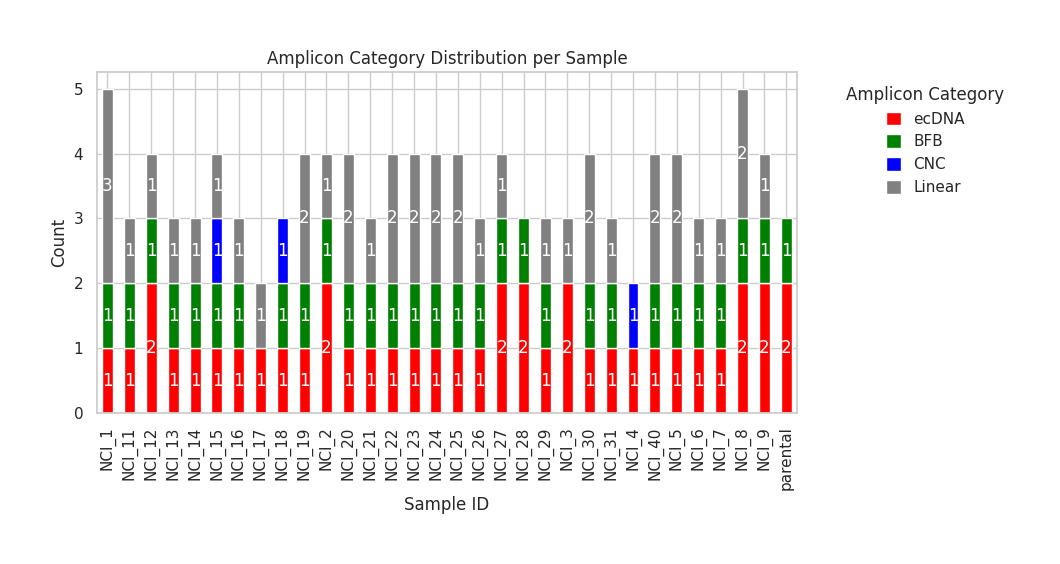

In [337]:
import matplotlib.pyplot as plt

# none 제외
table_no_none = table.drop(columns=["none"], errors="ignore").copy()

# 표시 순서 고정
desired_order = [ "ecDNA", "BFB", "CNC","Linear"]
existing_cols = [c for c in desired_order if c in table_no_none.columns]
table_no_none = table_no_none[existing_cols]

# 원하는 색 지정
color_map = {
    "ecDNA": "red",
    "CNC": "blue",
    "BFB": "green",
    "Linear": "gray"
}
colors = [color_map[col] for col in table_no_none.columns]

# plot
ax = table_no_none.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=colors
)

# 각 bar segment 안에 숫자 넣기
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + height / 2
        ax.text(
            x, y, f"{int(height)}",
            ha="center", va="center",
            fontsize=12, color="white"
        )

plt.ylabel("Count")
plt.xlabel("Sample ID")
plt.title("Amplicon Category Distribution per Sample")
plt.legend(title="Amplicon Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [338]:
amplicon_ERBB2 = df[df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]
print(amplicon_ERBB2.shape)
amplicon_ERBB2.head(2)

(32, 28)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type,old_source_barcode,old_sample_id
115,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon5,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon5,Cyclic,Positive,None detected,1,5,amplicon5,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,4,"3:111173572-111384597,8:102089822-102300847,8:...","C17orf37,THRA,CDC6,RARA,CDK12,CSF3,ERBB2,PVT1,...",3507058,2238296,165.354504,3,24,10,10,5,0,0,H2170,NCI_9,ecDNA,H2170,NCI_9
139,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J-amplicon5,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J,amplicon5,Cyclic,Positive,None detected,1,5,amplicon5,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,4,"3:111173653-111384516,8:102089903-102300766,8:...","RARA,PVT1,MYC,CDK12,ERBB2,C17orf37,CSF3,THRA,C...",3506734,2692857,186.582499,3,22,9,10,5,1,0,H2170,NCI_26,ecDNA,H2170,NCI_26


In [339]:
df[(df['amplicon_type']=='ecDNA')&(df['sample_id']=='parental')]['Intervals'].tolist()


['8:43225919-43227230,14:32583156-32584467,14:34639918-40644889',
 '3:111173429-111384740,8:102090543-102301854,8:127916498-130061502,14:22159983-26689961,17:37630838-38570838']

In [340]:
# amplicon_ERBB2.to_csv('../summary/amplicon_ERBB2_EFM192A.csv',index=False)

In [341]:
amplicon_ERBB2_AND_chr14 = df[(df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False))|(df['Intervals'].str.contains('14:'))|(df['amplicon_type']=='ecDNA')]
print(amplicon_ERBB2_AND_chr14.shape)

amplicon_ERBB2_AND_chr14 = amplicon_ERBB2_AND_chr14[amplicon_ERBB2_AND_chr14['amplicon_type']!='none']
print(amplicon_ERBB2_AND_chr14.shape)

# No amp/Invalid
# amplicon_ERBB2.to_csv('../summary/amplicon_ERBB2_NCI_H2170.csv',index=False)
# amplicon_ERBB2_AND_chr14.to_csv('../summary/amplicon_ERBB2_NCI_H2170_withChr14.csv',index=False)

(126, 28)
(71, 28)


In [342]:
all_samples = amplicon_ERBB2['sample_id'].unique().tolist()

# ecDNA를 하나라도 가지고 있는 샘플 리스트 추출
ecDNA_samples = amplicon_ERBB2[amplicon_ERBB2['amplicon_type'] == 'ecDNA']['sample_id'].unique().tolist()

# 그룹 분리 (parental 제외)
ecDNA_clones = [s for s in ecDNA_samples if s != 'parental']
other_clones = [s for s in all_samples if s not in ecDNA_samples and s != 'parental']

# 최종 순서: parental -> ecDNA 클론(알파벳순) -> 나머지 클론(알파벳순)
sample_order = []
if 'parental' in all_samples:
    sample_order.append('parental')

sample_order.extend(sorted(ecDNA_clones))
sample_order.extend(sorted(other_clones))

# sample_id를 정의한 순서대로 Categorical 타입 변환
amplicon_ERBB2['sample_id'] = pd.Categorical(
    amplicon_ERBB2['sample_id'], 
    categories=sample_order, 
    ordered=True
)

<ipython-input-342-1adfd421b1ef>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amplicon_ERBB2['sample_id'] = pd.Categorical(


In [343]:
# 비교하고 싶은 주요 수치형 컬럼들
metrics = [
    'N_Chromosomes', 'N_BreakpointEdges', 'TotalIntervalSize', 
    'AmplifiedIntervalSize', 'AverageAmplifiedCopyCount'
]

# 샘플별 평균 통계량 계산
summary_stats = amplicon_ERBB2.groupby('sample_id')[metrics].agg(['mean', 'std', 'count']).round(2)
print(summary_stats)

# CSV로 저장하여 나중에 Nextflow 리포트 등에 활용 가능
# summary_stats.to_csv("ERBB2_amplicon_stats_summary.csv")

          N_Chromosomes           N_BreakpointEdges             
                   mean std count              mean std count   
sample_id                                                       
parental            4.0 NaN     1              11.0 NaN     1  \
NCI_1               3.0 NaN     1              10.0 NaN     1   
NCI_11              3.0 NaN     1              10.0 NaN     1   
NCI_12              3.0 NaN     1              14.0 NaN     1   
NCI_13              3.0 NaN     1              10.0 NaN     1   
NCI_14              3.0 NaN     1              10.0 NaN     1   
NCI_15              3.0 NaN     1              10.0 NaN     1   
NCI_16              3.0 NaN     1              10.0 NaN     1   
NCI_17              4.0 NaN     1              16.0 NaN     1   
NCI_18              3.0 NaN     1              10.0 NaN     1   
NCI_19              3.0 NaN     1              10.0 NaN     1   
NCI_2               3.0 NaN     1              10.0 NaN     1   
NCI_20              3.0 N

<ipython-input-344-2192a7472f2a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount',
<ipython-input-344-2192a7472f2a>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_BreakpointEdges',
<ipython-input-344-2192a7472f2a>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='AmplifiedIntervalSize',
<ipython-input-344-2192a7472f2a>:34: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

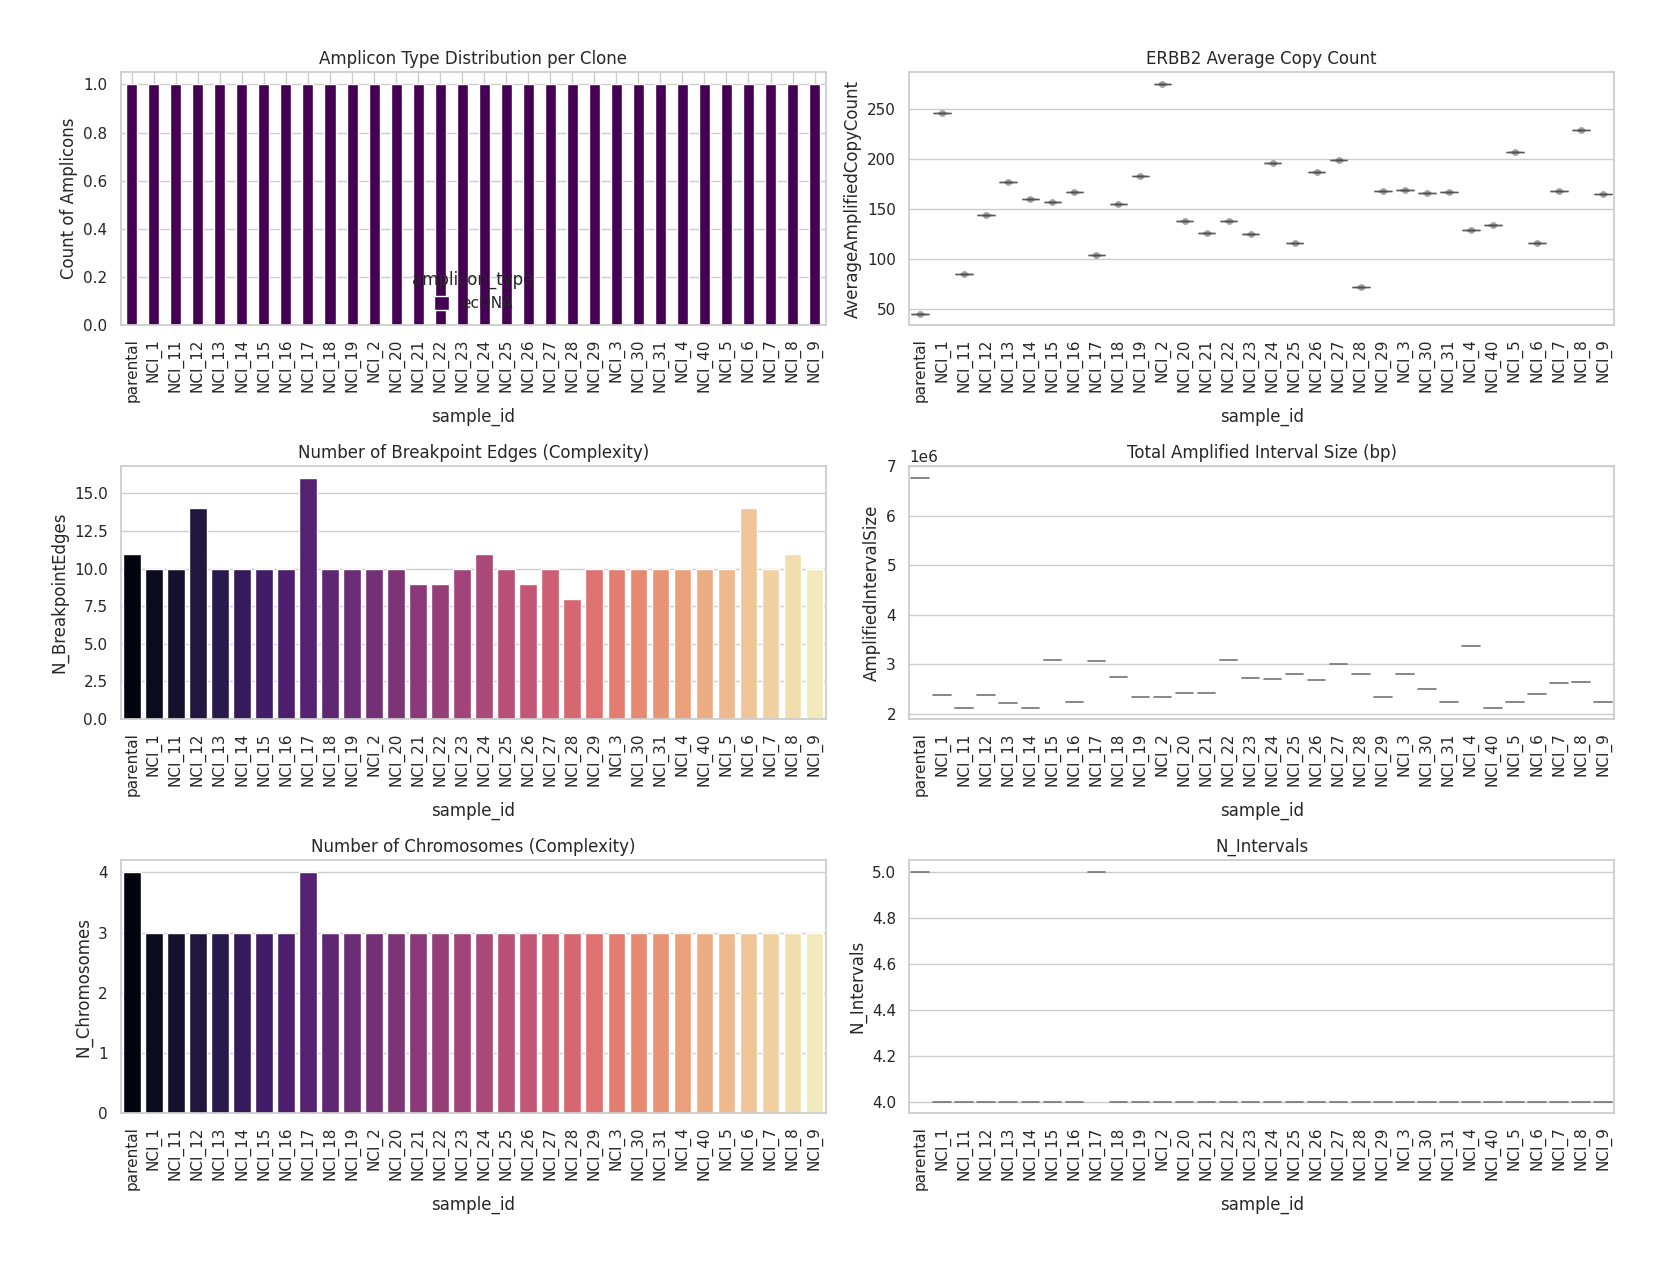

In [344]:
# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# (1) Amplicon Type 분포 (Stacked Bar)
# ecDNA, BFB 등의 구성 변화 확인
type_counts = amplicon_ERBB2.groupby(['sample_id', 'amplicon_type']).size().unstack(fill_value=0)
type_counts.loc[sample_order].plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='viridis')
axes[0, 0].set_title('Amplicon Type Distribution per Clone')
axes[0, 0].set_ylabel('Count of Amplicons')

# (2) Average Amplified Copy Count (Boxplot)
# ERBB2의 증폭 수준이 클론별로 어떻게 변하는지 확인
sns.boxplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount', 
            order=sample_order, ax=axes[0, 1], palette='Set2')
sns.stripplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount', 
              order=sample_order, ax=axes[0, 1], color=".3", alpha=0.5)
axes[0, 1].set_title('ERBB2 Average Copy Count')

# (3) Complexity: Breakpoint Edges
# 구조적 복잡도가 증가했는지 확인 (ecDNA 진화의 척도)
sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_BreakpointEdges', 
            order=sample_order, ax=axes[1, 0], errorbar='sd', palette='magma')
axes[1, 0].set_title('Number of Breakpoint Edges (Complexity)')

# (4) Amplified Interval Size
# 증폭된 영역의 전체 크기 비교
sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='AmplifiedIntervalSize', 
               order=sample_order, ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Total Amplified Interval Size (bp)')

# (5) N_Chromosomes: 
# 구조적 복잡도가 증가했는지 확인 (ecDNA 진화의 척도)
sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_Chromosomes', 
            order=sample_order, ax=axes[2, 0], errorbar='sd', palette='magma')
axes[2, 0].set_title('Number of Chromosomes (Complexity)')

# (6) Amplified Interval Size
# 증폭된 영역의 전체 크기 비교
sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='N_Intervals', 
               order=sample_order, ax=axes[2, 1], palette='Pastel1')
axes[2, 1].set_title('N_Intervals')

for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
# plt.savefig("ERBB2_clonal_comparison_plots.png", dpi=300)
plt.show()

In [345]:
# - ecDNA heterogeneity분석 프레임 짜기
# ~~~해석할사항: founder 상태 + 증식 과정에서 다시 생긴 ecDNA diversification의 합성 결과
# ~~~parental bulk 하나가 이미 여러 hidden lineage를 평균
#     1) parental
    
# A. Stable retention
# B. Retention with rewiring
# C. Class switch
# D. Loss
# E. De novo

In [346]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_bp_overlap(str1, str2):
    """두 Interval 문자열 간의 겹치는 bp 총합 계산"""
    def parse(s):
        res = []
        for item in s.split(','):
            chrom, pos = item.split(':')
            start, end = map(int, pos.split('-'))
            res.append((chrom, start, end))
        return res

    iv1, iv2 = parse(str1), parse(str2)
    overlap_total = 0
    for c1, s1, e1 in iv1:
        for c2, s2, e2 in iv2:
            if c1 == c2:
                inter_s, inter_e = max(s1, s2), min(e1, e2)
                if inter_s < inter_e:
                    overlap_total += (inter_e - inter_s)
    
    len1 = sum(e-s for _, s, e in iv1)
    len2 = sum(e-s for _, s, e in iv2)
    return overlap_total, len1, len2
import pandas as pd
import numpy as np

# 1. 통계 계산 루프 수정
parental_row = amplicon_ERBB2[amplicon_ERBB2['sample_id'] == 'parental'].iloc[0]
p_intervals = parental_row['Intervals']

comparison_results = []

for _, row in amplicon_ERBB2.iterrows():
    overlap, p_len, c_len = get_bp_overlap(p_intervals, row['Intervals'])
    
    # Jaccard: 전체적인 일치도 (교집합 / 합집합)
    jaccard = overlap / (p_len + c_len - overlap) if (p_len + c_len - overlap) > 0 else 0
    
    # Conservation: Parental의 영역 중 유지된 비율 (Parental 기준)
    conservation = (overlap / p_len) * 100 if p_len > 0 else 0
    
    # Clone_Source_Ratio: 클론의 구성 성분 중 Parental에서 온 비율 (Clone 기준)
    # 이 수치가 높을수록 "이 클론은 Parental의 파편으로 만들어졌다"는 의미입니다.
    clone_source_ratio = (overlap / c_len) * 100 if c_len > 0 else 0
    
    # Novelty: 클론이 새로 획득한 영역의 비율 (Clone 기준)
    novelty = 100 - clone_source_ratio

    comparison_results.append({
        'sample_id': row['sample_id'],
        'amplicon_type': row['amplicon_type'],
        'Jaccard_Similarity': jaccard,
        'Parental_Conservation_%': conservation,
        'Clone_Source_Ratio_%': clone_source_ratio,
        'Novel_Region_%': novelty,
        'Total_Size_bp': c_len,
        'Overlap_bp': overlap
    })

df_sim = pd.DataFrame(comparison_results)

# 정렬: 타입별로 묶고, 클론 소스 비율이 높은 순서대로
df_sim = df_sim.sort_values(by=['amplicon_type','Parental_Conservation_%', 'Clone_Source_Ratio_%'], ascending=[True, True,False])
df_sim

,sample_id,amplicon_type,Jaccard_Similarity,Parental_Conservation_%,Clone_Source_Ratio_%,Novel_Region_%,Total_Size_bp,Overlap_bp
22,NCI_28,ecDNA,0.436172,43.620562,99.982148,0.017852,3506674,3506048
1,NCI_26,ecDNA,0.436176,43.621084,99.981749,0.018251,3506730,3506090
9,NCI_24,ecDNA,0.436177,43.621233,99.981635,0.018365,3506746,3506102
15,NCI_17,ecDNA,0.390950,43.621345,79.025484,20.974516,4436684,3506111
2,NCI_30,ecDNA,0.436180,43.621495,99.981436,0.018564,3506774,3506123
16,NCI_27,ecDNA,0.436180,43.621569,99.981379,0.018621,3506782,3506129
30,NCI_23,ecDNA,0.436180,43.621569,99.981379,0.018621,3506782,3506129
18,NCI_31,ecDNA,0.436183,43.621943,99.981094,0.018906,3506822,3506159
10,NCI_22,ecDNA,0.436184,43.621980,99.981065,0.018935,3506826,3506162
29,NCI_20,ecDNA,0.436185,43.622092,99.980980,0.019020,3506838,3506171


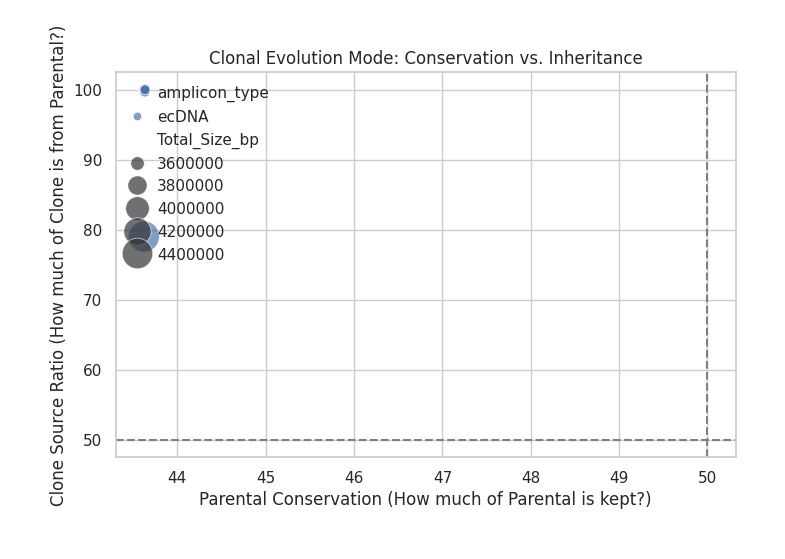

In [347]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_sim[df_sim['sample_id'] != 'parental'], 
    x='Parental_Conservation_%', 
    y='Clone_Source_Ratio_%', 
    hue='amplicon_type', 
    size='Total_Size_bp',
    sizes=(50, 500),
    alpha=0.7
)

plt.axvline(50, color='grey', linestyle='--')
plt.axhline(50, color='grey', linestyle='--')
plt.title('Clonal Evolution Mode: Conservation vs. Inheritance')
plt.xlabel('Parental Conservation (How much of Parental is kept?)')
plt.ylabel('Clone Source Ratio (How much of Clone is from Parental?)')
plt.show()

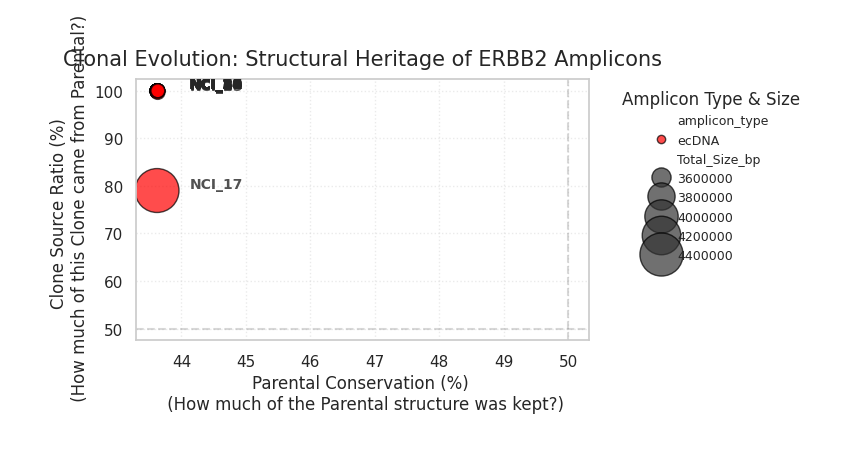

In [348]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 색상 팔레트 정의 (요청하신 색상 기준)
# ecDNA: Red, CNC: Blue, BFB: Green, 나머지는 Grey 계열
color_map = {
    'ecDNA': '#FF0000',   # Red
    'CNC': '#0000FF',     # Blue
    'BFB': '#008000',     # Green
    'Linear': '#808080',  # Grey (기타 타입 대비)
    'Complex non-cyclic': '#0000FF' # CNC의 풀네임 대비
}

plt.figure(figsize=(8, 4))

# 2. 'parental'을 제외한 클론들만 필터링
plot_df = df_sim[df_sim['sample_id'] != 'parental'].copy()

# 3. Scatter Plot 그리기
scatter = sns.scatterplot(
    data=plot_df, 
    x='Parental_Conservation_%', 
    y='Clone_Source_Ratio_%', 
    hue='amplicon_type', 
    palette=color_map, # 지정한 색상 적용
    size='Total_Size_bp',
    sizes=(100, 1000),
    alpha=0.7,
    edgecolor='black', # 점의 테두리를 그려서 가독성 높임
    linewidth=1
)

# 4. 각 점에 sample_id 라벨 추가 (plt.text 루프)
for i in range(plot_df.shape[0]):
    row = plot_df.iloc[i]
    plt.text(
        x=row['Parental_Conservation_%'] + 0.5, # 라벨이 점에 겹치지 않게 약간 오른쪽으로
        y=row['Clone_Source_Ratio_%'] + 0.5, 
        s=row['sample_id'], 
        fontsize=10, 
        fontweight='bold',
        alpha=0.8
    )

# 5. 가이드라인 및 서식 설정
plt.axvline(50, color='grey', linestyle='--', alpha=0.3)
plt.axhline(50, color='grey', linestyle='--', alpha=0.3)

plt.title('Clonal Evolution: Structural Heritage of ERBB2 Amplicons', fontsize=15, pad=10)
plt.xlabel('Parental Conservation (%) \n (How much of the Parental structure was kept?)', fontsize=12)
plt.ylabel('Clone Source Ratio (%) \n (How much of this Clone came from Parental?)', fontsize=12)

# 범례 설정 (그래프 바깥쪽으로 배치)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Amplicon Type & Size',fontsize=9)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [349]:
# A. structural heterogeneity
# 어떤 interval과 breakpoint가 남았는가

# B. topological heterogeneity
# round인가, non-circular/CNC인가, linear인가

# C. dosage heterogeneity
# copy number가 얼마인가

In [350]:
# intact inheritance

# fission into multiple ecDNAs

# selective streamlining

# class switch to CNC/linear

# loss

In [351]:
# OncogenesAmplified 컬럼의 쉼표로 구분된 유전자들을 explode
# 1. 먼저 쉼표(,)로 split → 리스트로 변환
df['OncogenesAmplified_split'] = df['OncogenesAmplified'].str.split(',')

# 2. explode를 통해 유전자별로 row 늘리기
df_exploded = df.explode('OncogenesAmplified_split')

# 3. 양끝 공백 제거 및 빈 문자열 제거
df_exploded['OncogenesAmplified_split'] = df_exploded['OncogenesAmplified_split'].str.strip()
df_exploded = df_exploded[df_exploded['OncogenesAmplified_split'] != '']

# 4. 컬럼명 정리
df_exploded = df_exploded.rename(columns={'OncogenesAmplified_split': 'Oncogene'})

# 결과 확인
print(df.shape,df_exploded.shape)
df_exploded.head()

(785, 29) (919, 29)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type,old_source_barcode,old_sample_id,Oncogene
98,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon12,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,8:133741504-136796510,"WISP1,NDRG1,",3055007,0,2.000000,1,1,0,0,0,0,0,H2170,NCI_9,none,H2170,NCI_9,WISP1
98,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon12,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,8:133741504-136796510,"WISP1,NDRG1,",3055007,0,2.000000,1,1,0,0,0,0,0,H2170,NCI_9,none,H2170,NCI_9,NDRG1
102,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon16,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon16,No amp/Invalid,None detected,None detected,0,16,amplicon16,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,11:69354762-70359653,"FGF4,FGF3,CCND1,CTTN,",1004892,358637,2.551789,1,3,0,2,0,0,2,H2170,NCI_9,none,H2170,NCI_9,FGF4
102,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon16,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon16,No amp/Invalid,None detected,None detected,0,16,amplicon16,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,11:69354762-70359653,"FGF4,FGF3,CCND1,CTTN,",1004892,358637,2.551789,1,3,0,2,0,0,2,H2170,NCI_9,none,H2170,NCI_9,FGF3
102,ECTRES-H2170-0001-TPX-A09-WGS-6XP120-amplicon16,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon16,No amp/Invalid,None detected,None detected,0,16,amplicon16,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,11:69354762-70359653,"FGF4,FGF3,CCND1,CTTN,",1004892,358637,2.551789,1,3,0,2,0,0,2,H2170,NCI_9,none,H2170,NCI_9,CCND1


## AA gene list

In [352]:
sample_mapping.head(2)

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id,aa_barcode
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949


In [353]:
df_exploded['amplicon_type'].unique()

array(['none', 'ecDNA', 'BFB', 'Linear', 'CNC'], dtype=object)

In [354]:
sample_order = (
    df_exploded["sample_id"]
    .unique()
)

sample_order = sorted(
    sample_order,
    key=lambda x: (x != "parental", x)
)

cn_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="AverageAmplifiedCopyCount"
).reindex(columns=sample_order)

cat_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="amplicon_type"
).reindex(columns=sample_order)

color_map = {
    "ecDNA": "red",                 # red
    "BFB": "green",                   # orange
    "Linear": "gray",  # blue
    "CNC": "blue",    # green
    "none": "white"                # gray
}

In [355]:
fig, ax = plt.subplots(figsize=(12, 10))

n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        
        color = color_map.get(category, "white")
        
        # 사각형 그리기
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax.add_patch(rect)
        
        # CN 숫자 annotation
        if not pd.isna(value):
            ax.text(
                j + 0.5,
                i + 0.5,
                int(value),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

ax.set_xlim(0, n_samples)
ax.set_ylim(0, n_genes)

ax.set_xticks(np.arange(n_samples) + 0.5)
ax.set_xticklabels(cn_matrix.columns, rotation=90)

ax.set_yticks(np.arange(n_genes) + 0.5)
ax.set_yticklabels(cn_matrix.index)

legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Amplicon Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)


ax.invert_yaxis()
plt.tight_layout()
# plt.show()

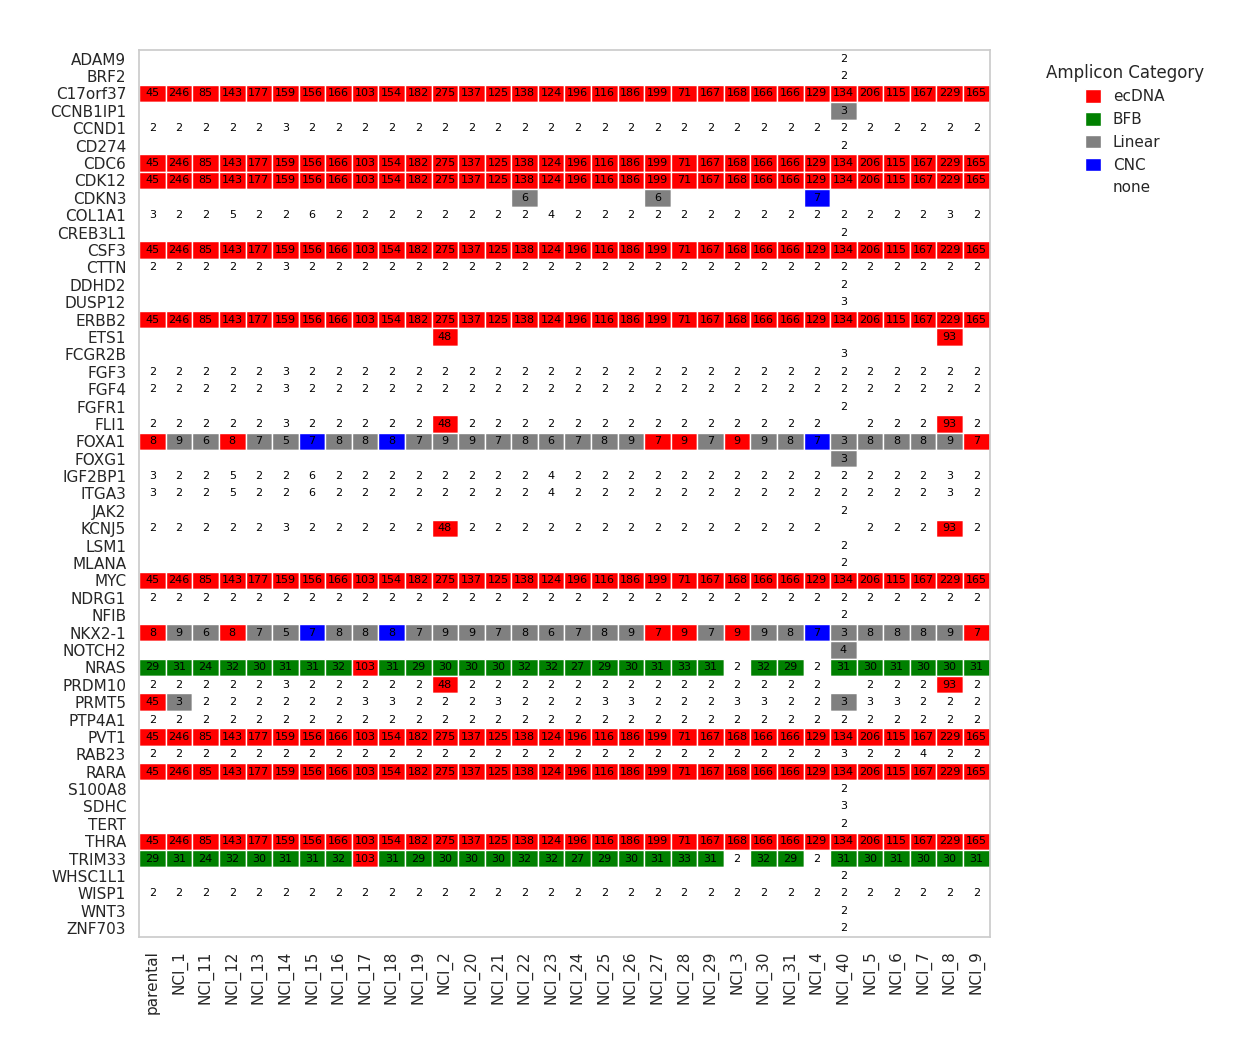

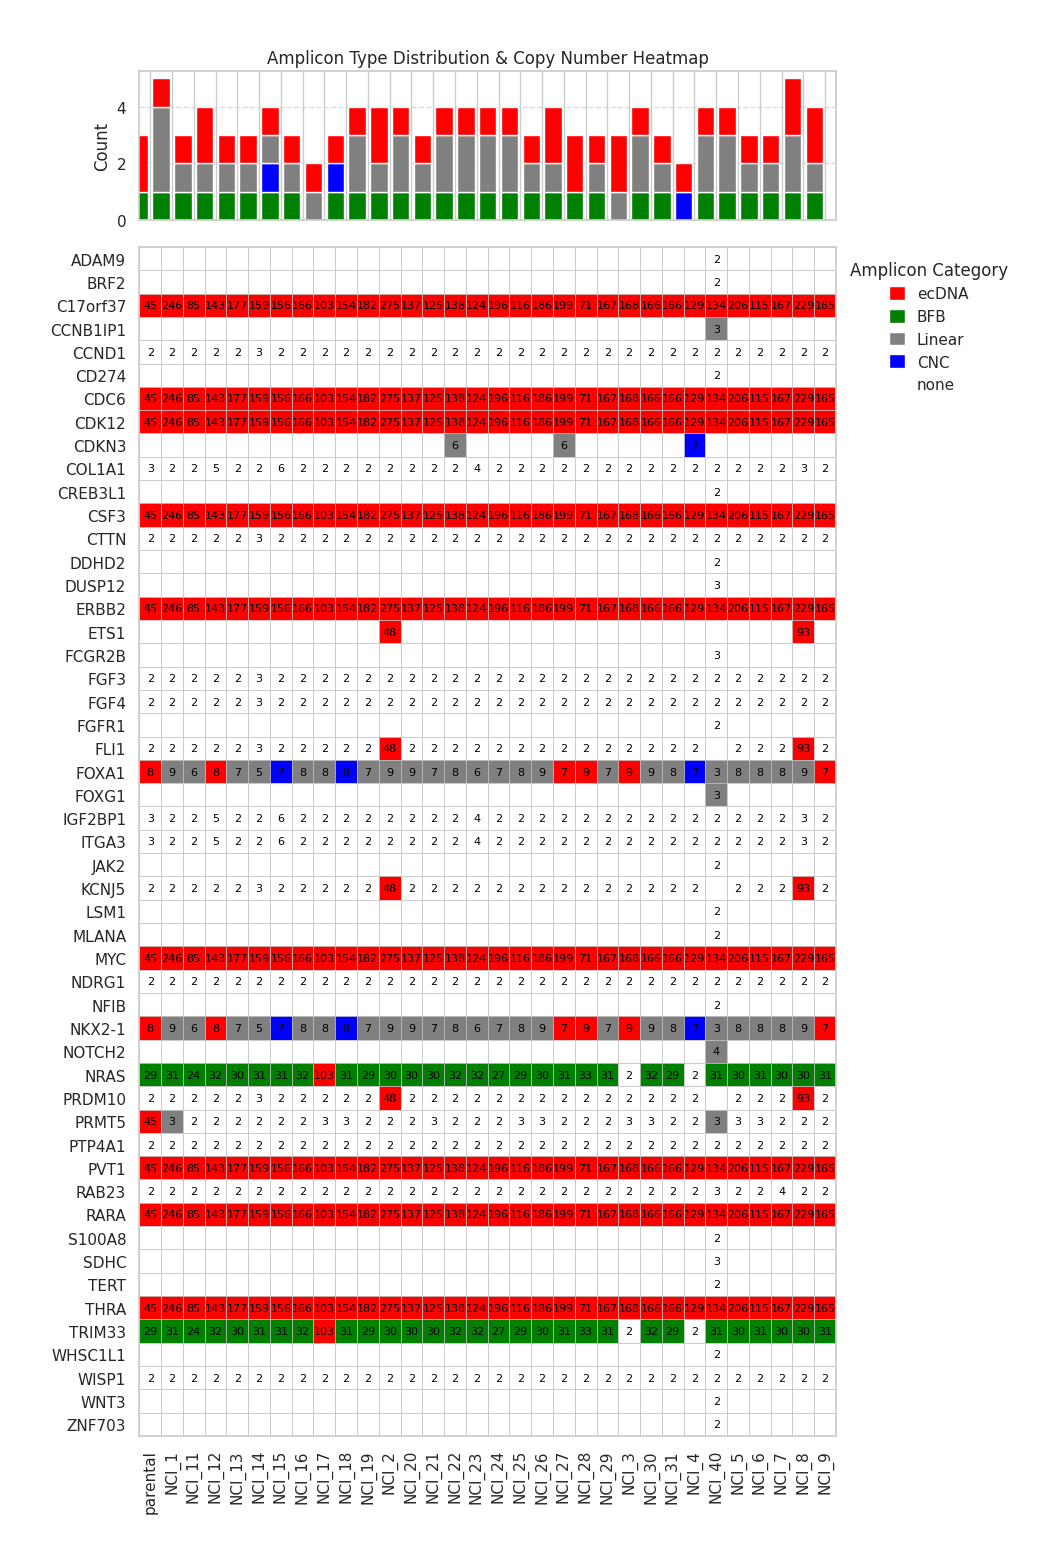

In [356]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# 1. 데이터 준비 (이미 정의되어 있다고 가정)
# amplicon_ERBB2: 원본 데이터프레임
# cn_matrix: 히트맵용 데이터
# sample_order: x축 샘플 순서 (cn_matrix.columns)

# 상단 바 차트를 위한 데이터 집계
# amplicon_type별 개수를 샘플 순서(cn_matrix.columns)에 맞춰 정렬


type_counts = df[df['amplicon_type']!='none'].groupby(['sample_id', 'amplicon_type']).size().unstack(fill_value=0)
type_counts = type_counts.reindex(cn_matrix.columns) 

# 2. Figure 생성 (상하로 2개의 영역 나눔, 높이 비율은 1:4)
fig, (ax_bar, ax_hm) = plt.subplots(2, 1, figsize=(10, 15), 
                                     sharex=True, 
                                     gridspec_kw={'height_ratios': [1, 8]})

# --- [상단: Stacked Bar Plot] ---
type_counts.plot(kind='bar', stacked=True, ax=ax_bar, color=color_map, width=0.8)
# ax_bar.set_xlim(-0.5, n_samples - 0.5)  # 왼쪽과 오른쪽에 0.5만큼 여유 공간 추가
ax_bar.set_title('Amplicon Type Distribution & Copy Number Heatmap')
ax_bar.set_ylabel('Count')
# ax_bar.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax_bar.legend('')

ax_bar.grid(axis='y', linestyle='--', alpha=0.7)

# --- [하단: Heatmap (기존 코드)] ---
n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        color = color_map.get(category, "white")
        
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='silver', lw=0.5)
        ax_hm.add_patch(rect)
        
        if not pd.isna(value):
            ax_hm.text(j + 0.5, i + 0.5, int(value),
                       ha="center", va="center", fontsize=8, color="black")

ax_hm.set_xlim(0, n_samples)
ax_hm.set_ylim(0, n_genes)

# X축 설정 (상단 ax_bar와 sharex=True 이므로 하단에만 라벨 표시)
ax_hm.set_xticks(np.arange(n_samples) + 0.5)
ax_hm.set_xticklabels(cn_matrix.columns, rotation=90)

# Y축 설정
ax_hm.set_yticks(np.arange(n_genes) + 0.5)
ax_hm.set_yticklabels(cn_matrix.index)
ax_hm.invert_yaxis()

# 히트맵용 범례
legend_elements = [Patch(facecolor=color, label=label) for label, color in color_map.items()]
ax_hm.legend(handles=legend_elements, title="Amplicon Category",
             bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.tight_layout()
# plt.subplots_adjust(hspace=0.05) # 바 차트와 히트맵 사이 간격 조절
plt.show()

### Clustering

In [357]:
# CN magnitude와 type을 곱해 하나의 구조-가중 CN으로 만들 수도 있습니다.
df_exploded["weighted_cn"] = (
    df_exploded["AverageAmplifiedCopyCount"] *
    df_exploded["amplicon_type"].map({
        "ecDNA": 5,
        "BFB": 3,
        "Linear amplification": 1,
        "Complex non-cyclic": 2,
        "none": 0
    })
)

cn_weighted = pd.pivot_table(
    df_exploded,
    index="sample_id",
    columns="Oncogene",
    values="weighted_cn",
    aggfunc="max"
).fillna(0)

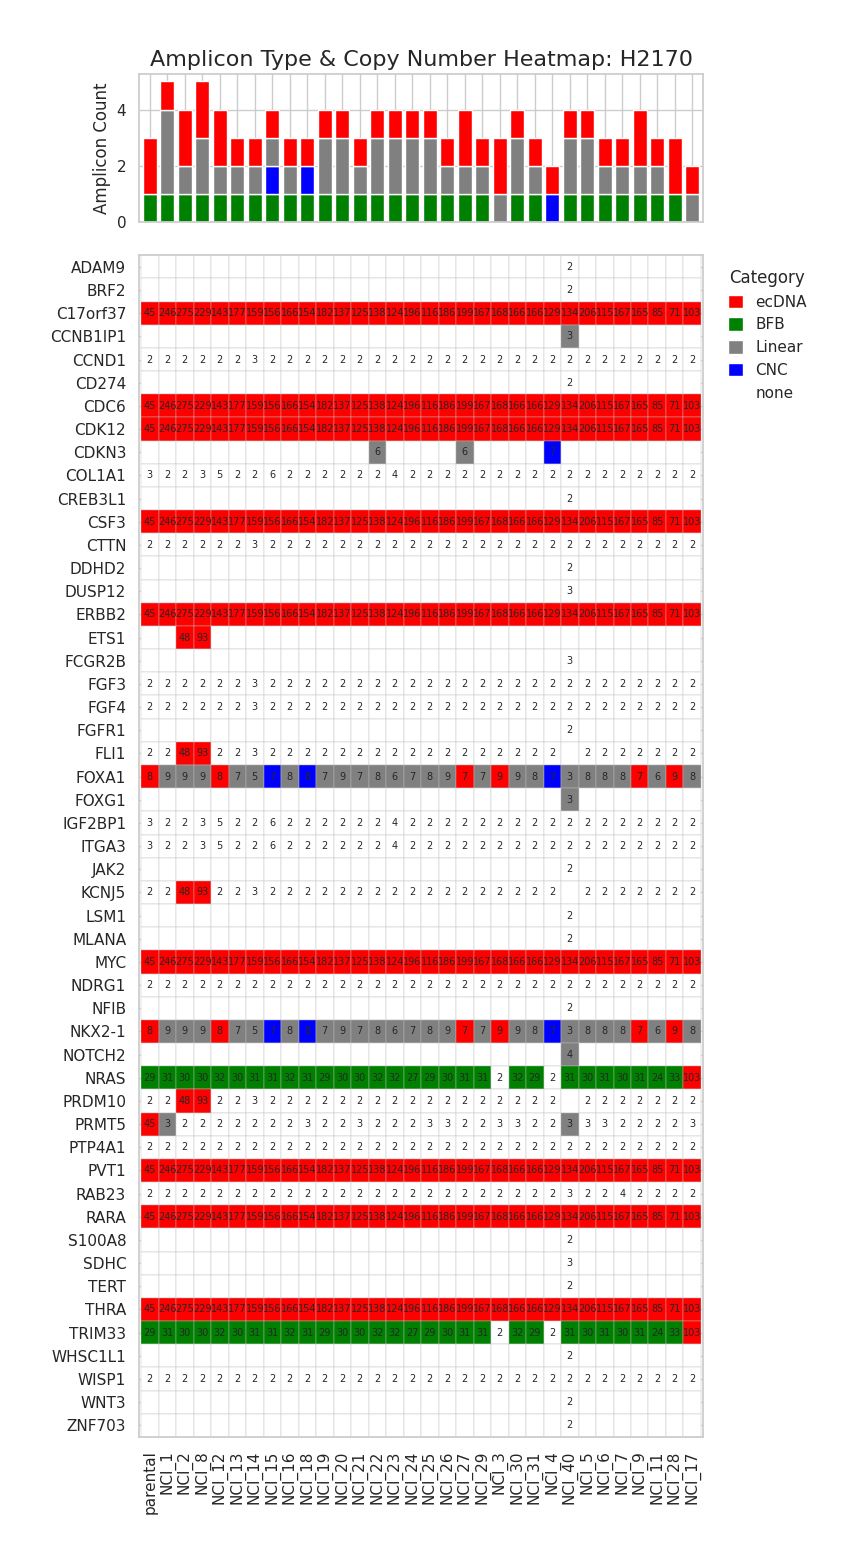

In [358]:

# 1. 클러스터링용 가중치 데이터 생성 (Parental 제외)
df_clones = df_exploded[df_exploded["sample_id"] != "parental"].copy()
df_clones["weighted_cn"] = df_clones["AverageAmplifiedCopyCount"] * df_clones["amplicon_type"].map({
    "ecDNA": 5, "Complex non-cyclic": 2, "BFB": 3, "Linear amplification": 1, "none": 0
}).fillna(0)

cn_weighted = pd.pivot_table(
    df_clones, index="sample_id", columns="Oncogene", 
    values="weighted_cn", aggfunc="max"
).fillna(0)

# 2. Hierarchical Clustering (5개 그룹)
dist_matrix = pdist(cn_weighted, metric="euclidean")
Z_clone = linkage(dist_matrix, method="average")
cluster_labels = fcluster(Z_clone, t=5, criterion="maxclust")

# 클러스터 결과 정리
cluster_df = pd.DataFrame({
    "sample_id": cn_weighted.index,
    "cluster_group": cluster_labels
}).sort_values(["cluster_group", "sample_id"])

# 3. 샘플 최종 순서 결정: [Parental] + [Clustered Clones]
ordered_samples = ["parental"] + cluster_df["sample_id"].tolist()

# 매트릭스 재정렬 (cn_matrix, cat_matrix는 기존에 생성된 데이터프레임 가정)
# 만약 parental이 matrix에 없다면 제외하고 정렬
final_samples = [s for s in ordered_samples if s in cn_matrix.columns]
cn_matrix_sub = cn_matrix[final_samples]
cat_matrix_sub = cat_matrix[final_samples]

# 상단 바 차트용 데이터 준비
# df[df['amplicon_type']!='none']
type_counts = df[df['amplicon_type']!='none'].groupby(['sample_id', 'amplicon_type']).size().unstack(fill_value=0)
type_counts = type_counts.reindex(final_samples).fillna(0)

# 4. 시각화 (상단 Bar + 하단 Heatmap)
fig, (ax_bar, ax_hm) = plt.subplots(2, 1, figsize=(8, 15), sharex=True, 
                                     gridspec_kw={'height_ratios': [1, 8]})

n_genes = cn_matrix_sub.shape[0]
n_samples = cn_matrix_sub.shape[1]

# --- 상단: Stacked Bar Plot ---
# 색상을 color_map과 통일 (있을 경우)
bar_colors = [color_map.get(t, "grey") for t in type_counts.columns]
type_counts.plot(kind='bar', stacked=True, ax=ax_bar, color=bar_colors, width=0.8)

ax_bar.set_title(f"Amplicon Type & Copy Number Heatmap: {source}", fontsize=16)
ax_bar.set_ylabel("Amplicon Count")
# ax_bar.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax_bar.legend('')

# --- 하단: Heatmap ---
for i in range(n_genes):
    for j in range(n_samples):
        category = cat_matrix_sub.iloc[i, j]
        value = cn_matrix_sub.iloc[i, j]
        color = color_map.get(category, "white")
        
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='silver', lw=0.3)
        ax_hm.add_patch(rect)
        
        if not pd.isna(value) and value > 0:
            ax_hm.text(j, i, int(value), ha="center", va="center", fontsize=7)

# 축 및 범위 설정 (여유 공간을 주어 parental이 잘리지 않게 함)
ax_hm.set_xlim(-0.6, n_samples - 0.4)
ax_hm.set_ylim(-0.5, n_genes - 0.5)
ax_hm.invert_yaxis()

ax_hm.set_xticks(range(n_samples))
ax_hm.set_xticklabels(final_samples, rotation=90)
ax_hm.set_yticks(range(n_genes))
ax_hm.set_yticklabels(cn_matrix_sub.index)

# 클러스터 경계선 (Parental 이후부터 계산)
# current_pos = 1  # Parental 위치 다음부터 시작
# for size in cluster_df.groupby("cluster_group").size():
#     current_pos += size
#     ax_hm.axvline(current_pos - 1.5, color="black", linewidth=1.5, linestyle="--")
# 클러스터 그룹별 샘플 개수 확인 (정렬된 순서대로)
group_counts = cluster_df.groupby("cluster_group", sort=False).size().tolist()

# 경계선 위치 계산
# index 0은 parental이므로, 첫 번째 경계선은 parental(0)과 첫 번째 클러스터 사이인 0.5 지점
# 그 다음 경계선들은 각 그룹의 누적 개수를 더한 위치
# boundaries = [0.5] 
# current = 0.5
# for count in group_counts:
#     current += count
#     boundaries.append(current)

# # Heatmap 코드 내부의 경계선 그리기 부분 수정
# for b in boundaries[:-1]: # 마지막 샘플 오른쪽 끝 선은 제외
#     ax_hm.axvline(x=b, color="black", linewidth=2, linestyle="--", alpha=0.8)
#     # 상단 바 차트에도 동일하게 경계선을 그려주면 정렬 확인이 쉽습니다.
#     ax_bar.axvline(x=b, color="black", linewidth=1.5, linestyle="--", alpha=0.5)

# # 축 범위 재설정 (깔끔하게)
# ax_hm.set_xlim(-0.5, n_samples - 0.5)

# 범례
legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax_hm.legend(handles=legend_elements, title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

In [359]:
# ecDNA는:uneven segregation/dynamic copy number change/structural instability
# => single-cell 유래 clone도 내부적으로 구조가 계속 변함
# clone ≠ genetically uniform population

# ✔ Oncogene CN
# ✔ Amplicon type
# ✔ PURPLE segment CN
# ✔ Amplicon complexity score
# ✔ ERBB2 locus SV or mutation

# "resistance mechanism이 다를 가능성이 높은 clone"을 분리???


# SV_summary

In [360]:
# ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_SV_summary_20260320.csv

aa_SV=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_SV_summary_20260320.csv')
# (1618, 15)
print(aa_SV.shape)
aa_SV.head()


(1618, 15)


,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,47244379,20,56230751,duplication-like,2,Linear,-+,47244380,56230750,0.0,NaN
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,47965687,20,54748124,inversion,2,NaN,--,47965688,54748125,0.0,NaN
4,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon2,1,57151411,8,117296688,interchromosomal,2,NaN,-+,57151412,117296687,NaN,NaN


In [361]:


aa_SV=pd.merge(aa_SV, aaSuite_gemline_ms[['aa_barcode','amplicon_number','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_number'])
print(aa_SV.shape) #(1618, 18)

aa_SV['sample_amp']=aa_SV['sample_id']+'-'+aa_SV['amplicon_number']


aa_SV_sub = aa_SV[(aa_SV['source_barcode']==source)]

print(aa_SV_sub.shape) #(690, 18)

aa_SV_sub.head(2)




(1618, 18)
(533, 19)


,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp
406,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,35581234,14,40323254,duplication-like,2,ecDNA,-+,35581235,40323253,-1.0,A,H2170,NCI_9,ecDNA,NCI_9-amplicon19
407,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,36482109,14,37358131,duplication-like,3,ecDNA,-+,36482110,37358130,2.0,CC,H2170,NCI_9,ecDNA,NCI_9-amplicon19


In [362]:
# aa_SV[(aa_SV['sample_id']=='NCI_40')]

In [363]:
# amplicon_type별 sv_type 빈도 계산
sv_summary = aa_SV_sub.groupby(['amplicon_type', 'sv_type']).size().unstack(fill_value=0)
sv_summary

sv_type,duplication-like,foldback,interchromosomal,inversion
amplicon_type,,,,
BFB,0,117,0,2
CNC,4,1,0,3
Linear,12,6,0,8
ecDNA,91,10,157,111
none,10,1,0,0


In [364]:
df=aa_SV_sub.copy()
# 1. 데이터 분리
parental_sv = df[df['sample_id'] == 'parental'].copy()
test_sv = df[df['sample_id'] != 'parental'].copy()


In [365]:
def calculate_sv_precision(row, ref_df):
    # 1. 염색체 쌍과 SV 타입이 같은 Parental 후보군 필터링
    match = ref_df[
        (ref_df['chrom1'] == row['chrom1']) & 
        (ref_df['chrom2'] == row['chrom2']) &
        (ref_df['sv_type'] == row['sv_type'])
    ]
    
    if match.empty:
        return pd.Series([np.nan, np.nan, np.nan, "De-novo (No matching chr/type)"])

    # 2. 모든 후보와의 거리 계산 (pos1, pos2 각각)
    diffs = pd.DataFrame({
        'd1': (match['pos1'] - row['pos1']).abs(),
        'd2': (match['pos2'] - row['pos2']).abs()
    })
    diffs['total_d'] = diffs['d1'] + diffs['d2']
    
    # 가장 '가까운' 세트를 선택
    best_match = diffs.loc[diffs['total_d'].idxmin()]
    d1, d2 = best_match['d1'], best_match['d2']
    
    max_d = max(d1, d2)
    min_d = min(d1, d2)  # 새로 추가: 둘 중 덜 차이 나는 거리

    # 3. 디테일한 카테고리 분류 (Anchored 개념 추가)
    if max_d == 0:
        grade = "Exact Match (0bp)"
        
    elif max_d <= 10:
        grade = "Near Match (≤10bp)"
        
    elif max_d <= 50:
        # 양쪽 다 50bp 이내로 움직인 경우 (마이크로호몰로지 등 미세 조정)
        grade = "Similar (Both ≤50bp)"
        
    elif max_d <= 500:
        # 최대 거리가 500bp 이하이면서...
        if min_d == 0:
            grade = "Anchored Distal (One end 0bp, One end ≤500bp)"
        else:
            grade = "Distal (Both shifted ≤500bp)"
            
    else: # max_d > 500 (완전히 새로운 위치로 날아간 경우)
        if min_d == 0:
            grade = "Anchored De-novo (One end 0bp, One end shifted)"
        else:
            grade = "De-novo (Both shifted)"

    return pd.Series([d1, d2, max_d, grade])

# 실제 적용
test_sv[['dist_pos1', 'dist_pos2', 'max_dist', 'similarity_grade']] = test_sv.apply(
    lambda x: calculate_sv_precision(x, parental_sv), axis=1
)

test_sv['sample_amp']=test_sv['sample_id']+'-'+test_sv['amplicon_number']
test_sv.head()

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade
406,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,35581234,14,40323254,duplication-like,2,ecDNA,-+,35581235,40323253,-1.0,A,H2170,NCI_9,ecDNA,NCI_9-amplicon19,0.0,0.0,0.0,Exact Match (0bp)
407,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,36482109,14,37358131,duplication-like,3,ecDNA,-+,36482110,37358130,2.0,CC,H2170,NCI_9,ecDNA,NCI_9-amplicon19,11615.0,573974.0,573974.0,De-novo (Both shifted)
408,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,114743716,1,114744728,foldback,5,BFB,--,114743717,114744729,-3.0,AAG,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp)
409,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,115138176,1,115139129,foldback,4,BFB,--,115138177,115139130,-2.0,AT,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp)
410,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,115466534,1,115469387,foldback,6,BFB,++,115466533,115469386,3.0,CAC,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp)


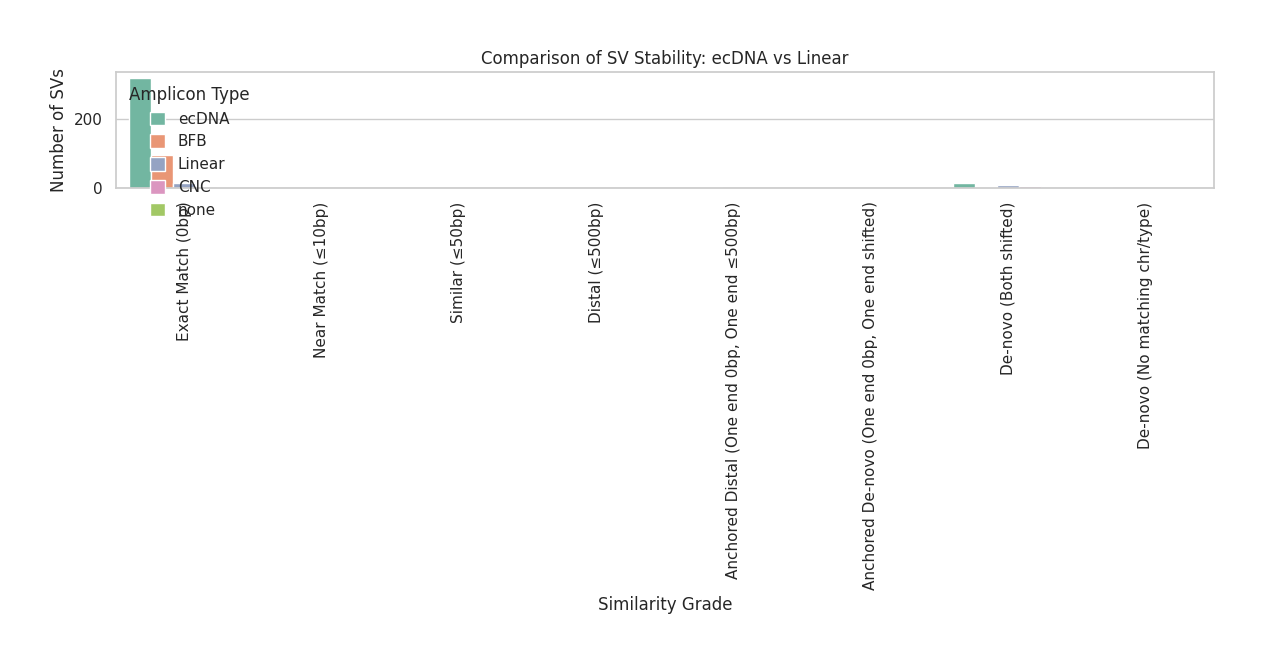

In [366]:
# 순서 고정
order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)",'Anchored Distal (One end 0bp, One end ≤500bp)','Anchored De-novo (One end 0bp, One end shifted)','De-novo (Both shifted)', "De-novo (No matching chr/type)"]

plt.figure(figsize=(12, 6))
# 비율(Percentage)로 시각화
sns.countplot(data=test_sv, x='similarity_grade', hue='amplicon_type', 
              order=order, palette='Set2')

plt.xticks(rotation=90)
plt.title('Comparison of SV Stability: ecDNA vs Linear')
plt.xlabel('Similarity Grade')
plt.ylabel('Number of SVs')
plt.legend(title='Amplicon Type')
plt.tight_layout()
plt.show()

# plt.savefig('sv_similarity_comparison.png')

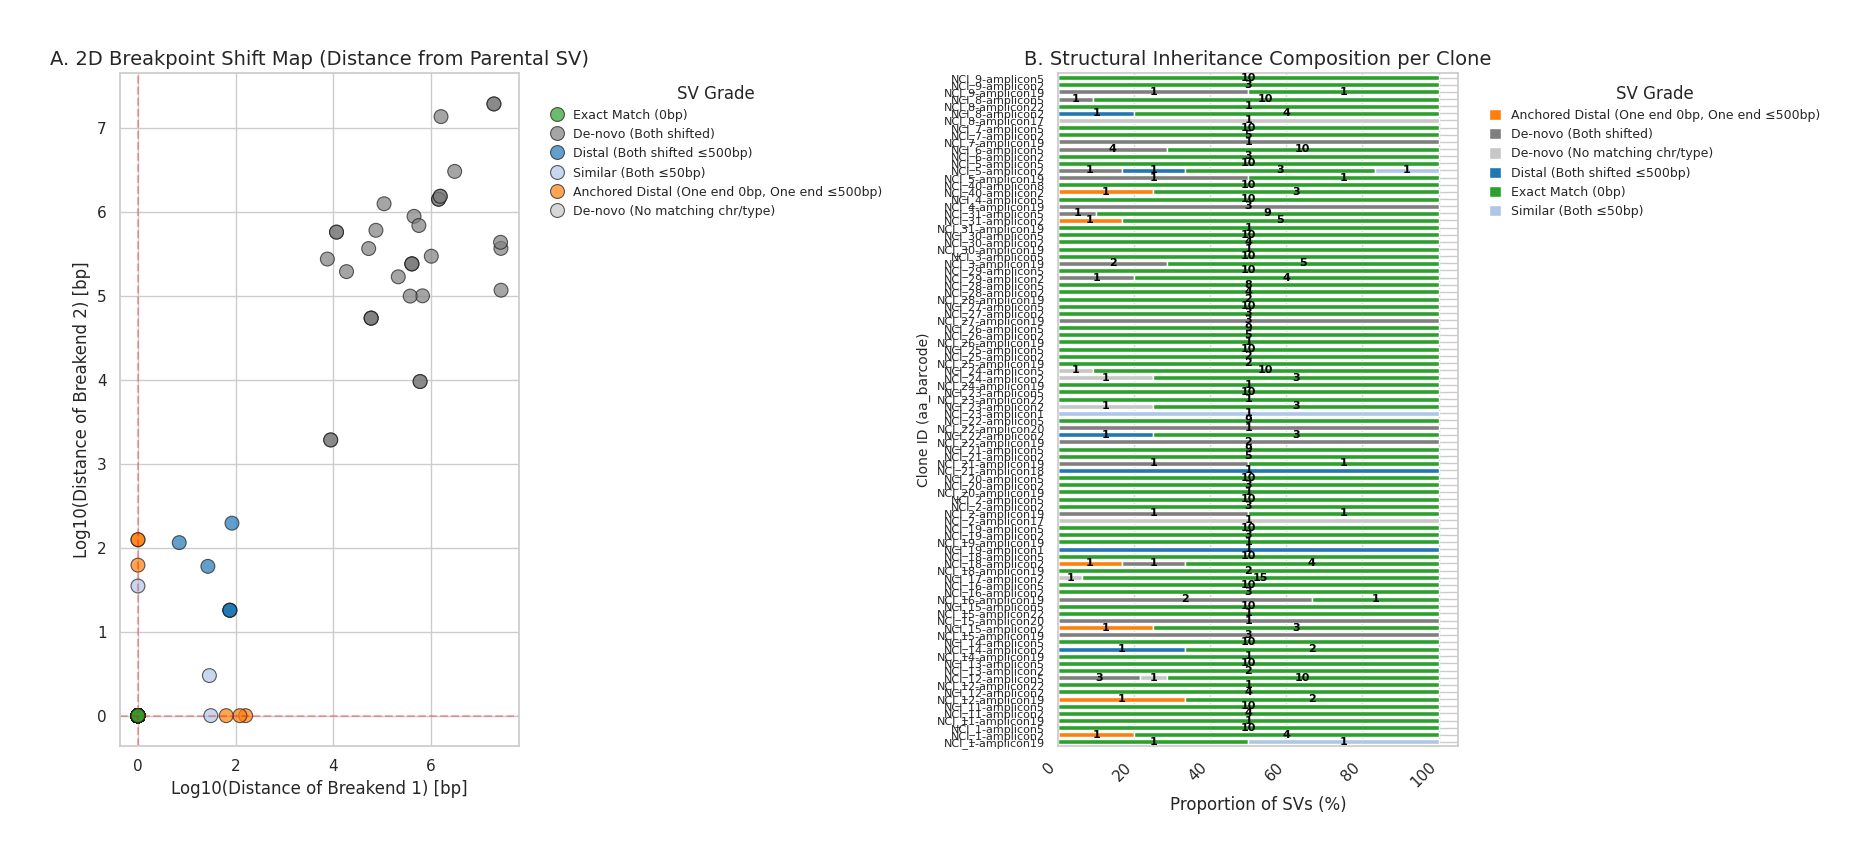

In [367]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 거리에 +1을 해주는 이유: log10(0)은 에러가 나기 때문입니다.
test_sv['log10_d1'] = np.log10(test_sv['dist_pos1'] + 1)
test_sv['log10_d2'] = np.log10(test_sv['dist_pos2'] + 1)

# 카테고리별 색상 지정 (논문용 팔레트)
grade_colors = {
    "Exact Match (0bp)": "#2ca02c",          # 녹색 (완벽 일치)
    "Near Match (≤10bp)": "#98df8a",         # 연두색
    "Similar (Both ≤50bp)": "#aec7e8",       # 연파랑
    "Anchored Distal (One end 0bp, One end ≤500bp)": "#ff7f0e", # 주황색 (관심 타겟!)
    "Distal (Both shifted ≤500bp)": "#1f77b4", # 진파랑
    "Anchored De-novo (One end 0bp, One end shifted)": "#d62728", # 빨간색 (핵심 타겟!)
    "De-novo (Both shifted)": "#7f7f7f",     # 회색
    "De-novo (No matching chr/type)": "#c7c7c7"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---------------------------------------------------------
# [Panel A] 2D Breakpoint Shift Scatter Plot
# ---------------------------------------------------------
sns.scatterplot(
    data=test_sv, x='log10_d1', y='log10_d2',
    hue='similarity_grade', palette=grade_colors,
    s=100, alpha=0.7, ax=axes[0], edgecolor='k'
)

# 축 가이드라인 (Anchored를 보여주는 선)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.3)

axes[0].set_title('A. 2D Breakpoint Shift Map (Distance from Parental SV)', fontsize=14)
axes[0].set_xlabel('Log10(Distance of Breakend 1) [bp]', fontsize=12)
axes[0].set_ylabel('Log10(Distance of Breakend 2) [bp]', fontsize=12)
axes[0].legend(title='SV Grade', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# ---------------------------------------------------------
# [Panel B] SV Composition Stacked Bar Plot (가로형 + 원본 개수 표시)
# ---------------------------------------------------------
# 1. 클론(sample_id)별로 grade 원본 개수(Count) 데이터프레임 생성
comp_df = test_sv.groupby(['sample_amp', 'similarity_grade']).size().unstack(fill_value=0)

# 2. 비율(%) 데이터프레임으로 변환 (막대그래프의 길이 기준)
comp_df_perc = comp_df.div(comp_df.sum(axis=1), axis=0) * 100

# 3. 색상 매핑
plot_colors = [grade_colors[col] for col in comp_df_perc.columns if col in grade_colors]

# 4. 가로 누적 막대그래프(비율 기준) 그리기
comp_df_perc.plot(kind='barh', stacked=True, color=plot_colors, ax=axes[1], edgecolor='white', width=0.7)

# 💡 5. 각 막대 블록 정중앙에 '실제 개수' 텍스트 삽입하기
for n, container in enumerate(axes[1].containers):
    # 현재 순회 중인 Grade의 이름과 실제 개수 데이터
    grade_name = comp_df_perc.columns[n]
    counts = comp_df[grade_name]
    
    for i, patch in enumerate(container):
        count = counts.iloc[i]
        
        # 0개인 경우는 라벨 생략하여 깔끔하게 유지
        if count > 0: 
            # 막대의 x축(너비 중심)과 y축(높이 중심) 좌표 계산
            x_center = patch.get_x() + patch.get_width() / 2
            y_center = patch.get_y() + patch.get_height() / 2
            
            # 개수 텍스트 삽입
            axes[1].text(
                x_center, y_center, str(int(count)), 
                ha='center', va='center', 
                fontsize=8, fontweight='bold', color='black' # 어두운 색상 배경이면 'white'로 변경 추천
            )

# 6. 축 및 서식 지정
axes[1].set_title('B. Structural Inheritance Composition per Clone', fontsize=14)
axes[1].set_xlabel('Proportion of SVs (%)', fontsize=12)
axes[1].set_ylabel('Clone ID (aa_barcode)', fontsize=10)
axes[1].tick_params(axis='y',labelsize=8, rotation=0)

# 범례 처리
axes[1].legend(title='SV Grade', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

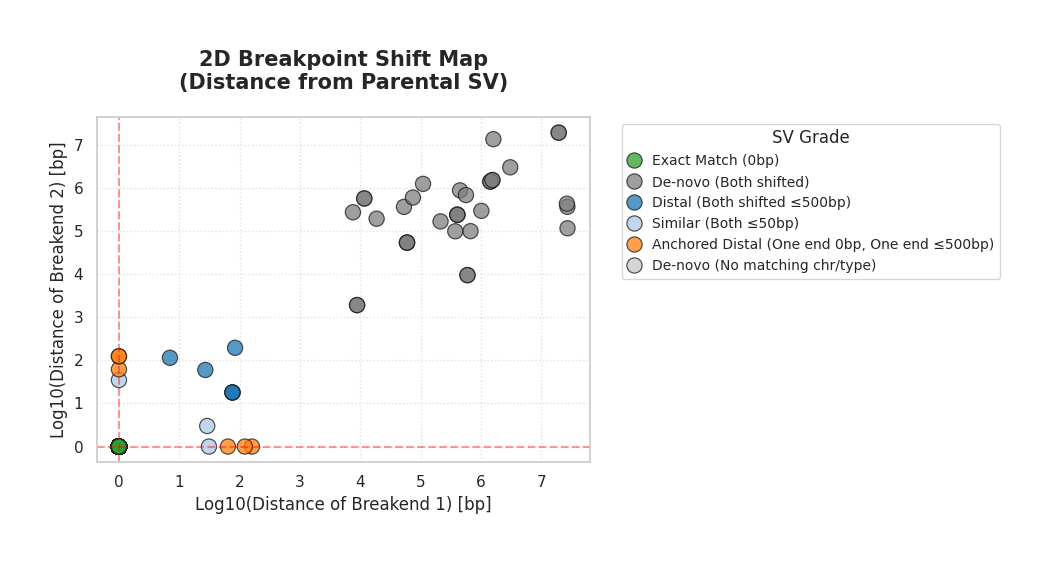

In [368]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 전처리 (이미 되어 있다면 생략 가능)
# test_sv['log10_d1'] = np.log10(test_sv['dist_pos1'] + 1)
# test_sv['log10_d2'] = np.log10(test_sv['dist_pos2'] + 1)

# 2. 카테고리별 색상 지정
grade_colors = {
    "Exact Match (0bp)": "#2ca02c",
    "Near Match (≤10bp)": "#98df8a",
    "Similar (Both ≤50bp)": "#aec7e8",
    "Anchored Distal (One end 0bp, One end ≤500bp)": "#ff7f0e",
    "Distal (Both shifted ≤500bp)": "#1f77b4",
    "Anchored De-novo (One end 0bp, One end shifted)": "#d62728",
    "De-novo (Both shifted)": "#7f7f7f",
    "De-novo (No matching chr/type)": "#c7c7c7"
}

# 3. Figure 생성 (단독 plot이므로 크기 조정)
fig, ax = plt.subplots(figsize=(10, 5))

# 4. Scatter Plot 그리기
sns.scatterplot(
    data=test_sv, 
    x='log10_d1', 
    y='log10_d2',
    hue='similarity_grade', 
    palette=grade_colors,
    s=120,            # 점 크기를 조금 더 키움
    alpha=0.75, 
    edgecolor='k',    # 테두리 추가로 점 구분 명확히
    ax=ax
)

# 5. 가이드라인 (Anchored 및 Exact Match 강조)
ax.axvline(0, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
ax.axhline(0, color='red', linestyle='--', alpha=0.4, linewidth=1.5)

# 6. 서식 설정
ax.set_title('2D Breakpoint Shift Map\n(Distance from Parental SV)', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Log10(Distance of Breakend 1) [bp]', fontsize=12)
ax.set_ylabel('Log10(Distance of Breakend 2) [bp]', fontsize=12)

# 범례 설정 (오른쪽 바깥으로 배치)
ax.legend(title='SV Grade', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10)

# 그리드 추가로 로그 스케일 가독성 향상
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig("SV_Shift_Map.png", dpi=300) # 저장 필요 시 주석 해제
plt.show()

In [214]:
test_sv.head()

# test_sv[(test_sv['sample_id']=='EFM_1')&(test_sv['amplicon_number']=='amplicon9')&(test_sv['origin_label']!='Parental-derived')]

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade,log10_d1,log10_d2
406,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,35581234,14,40323254,duplication-like,2,ecDNA,-+,35581235,40323253,-1.0,A,H2170,NCI_9,ecDNA,NCI_9-amplicon19,0.0,0.0,0.0,Exact Match (0bp),0.000000,0.000000
407,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,36482109,14,37358131,duplication-like,3,ecDNA,-+,36482110,37358130,2.0,CC,H2170,NCI_9,ecDNA,NCI_9-amplicon19,11615.0,573974.0,573974.0,De-novo (Both shifted),4.065057,5.758893
408,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,114743716,1,114744728,foldback,5,BFB,--,114743717,114744729,-3.0,AAG,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp),0.000000,0.000000
409,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,115138176,1,115139129,foldback,4,BFB,--,115138177,115139130,-2.0,AT,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp),0.000000,0.000000
410,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon2,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon2,1,115466534,1,115469387,foldback,6,BFB,++,115466533,115469386,3.0,CAC,H2170,NCI_9,BFB,NCI_9-amplicon2,0.0,0.0,0.0,Exact Match (0bp),0.000000,0.000000


In [215]:
amplicon_ERBB2['amp_barcode'] = amplicon_ERBB2['aa_barcode']+'_'+amplicon_ERBB2['amplicon_number']
amp_barcode_ERBB2 = amplicon_ERBB2['amp_barcode'].unique().tolist()
len(amp_barcode_ERBB2)
# amplicon_ERBB2.head(2)

32

In [216]:
amp_barcode_ERBB2

['ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon5',
 'ECTRES-H2170-0001-TPX-A26-WGS-BZG37J_amplicon5',
 'ECTRES-H2170-0001-TPX-A30-WGS-KUB89Z_amplicon5',
 'ECTRES-H2170-0001-TPX-A05-WGS-9ZM352_amplicon5',
 'ECTRES-H2170-0001-TPX-A03-WGS-0WE456_amplicon5',
 'ECTRES-H2170-0001-TPX-A13-WGS-1NY223_amplicon5',
 'ECTRES-H2170-0001-TPX-A15-WGS-1CS991_amplicon5',
 'ECTRES-H2170-0001-TPX-A08-WGS-5JD147_amplicon5',
 'ECTRES-H2170-0001-TPX-A25-WGS-MSZHL2_amplicon5',
 'ECTRES-H2170-0001-TPX-A24-WGS-MZU3A1_amplicon5',
 'ECTRES-H2170-0001-TPX-A22-WGS-KCXAQ5_amplicon5',
 'ECTRES-H2170-0001-TPX-A01-WGS-6TB808_amplicon5',
 'ECTRES-H2170-0001-TPX-A11-WGS-1DD808_amplicon5',
 'ECTRES-H2170-0001-TPX-A04-WGS-7PU017_amplicon5',
 'ECTRES-H2170-0001-TPX-A29-WGS-HQRCV3_amplicon5',
 'ECTRES-H2170-0001-TPX-A17-WGS-JXAF26_amplicon2',
 'ECTRES-H2170-0001-TPX-A27-WGS-LNCA46_amplicon5',
 'ECTRES-H2170-0001-TPX-A21-WGS-MXS5K1_amplicon5',
 'ECTRES-H2170-0001-TPX-A31-WGS-VZD4GS_amplicon5',
 'ECTRES-H2170-0001-TPX-A02-WGS

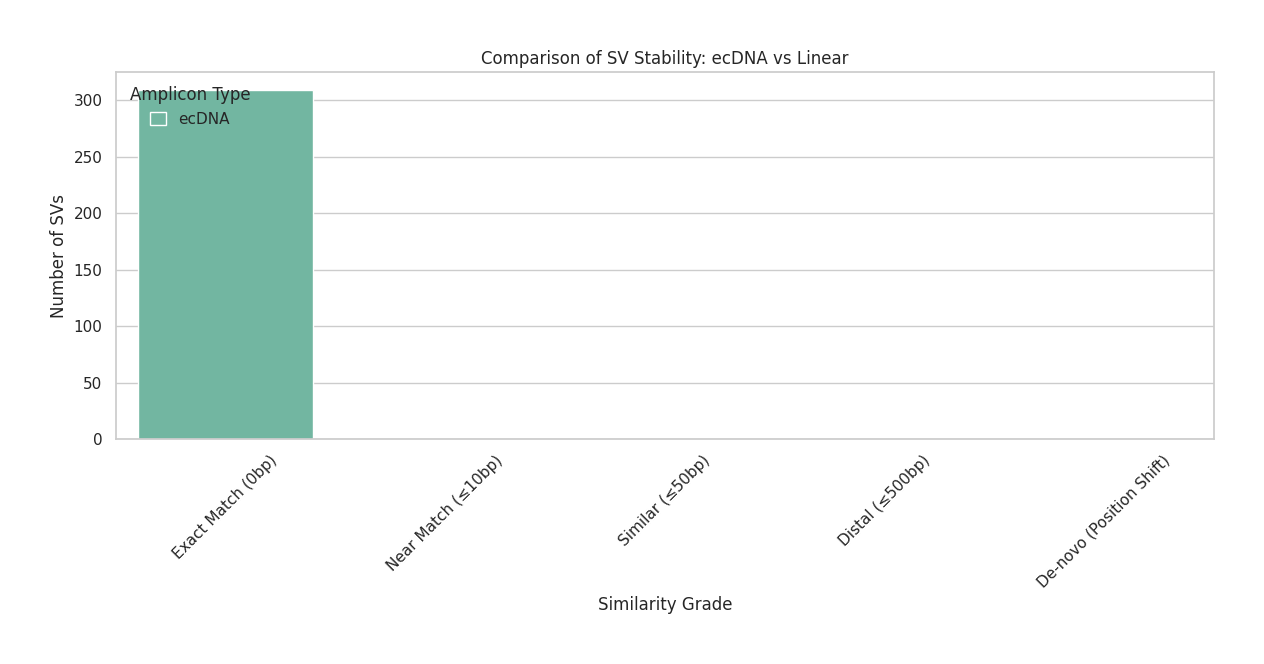

In [217]:
plot_df = test_sv[(test_sv['amplicon_barcode'].isin(amp_barcode_ERBB2))]

order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)", "De-novo (Position Shift)"]

plt.figure(figsize=(12, 6))
# 비율(Percentage)로 시각화
sns.countplot(data=plot_df, x='similarity_grade', hue='amplicon_type', 
              order=order, palette='Set2')

plt.xticks(rotation=45)
plt.title('Comparison of SV Stability: ecDNA vs Linear')
plt.xlabel('Similarity Grade')
plt.ylabel('Number of SVs')
plt.legend(title='Amplicon Type')
plt.tight_layout()
plt.show()

# plt.savefig('sv_similarity_comparison.png')

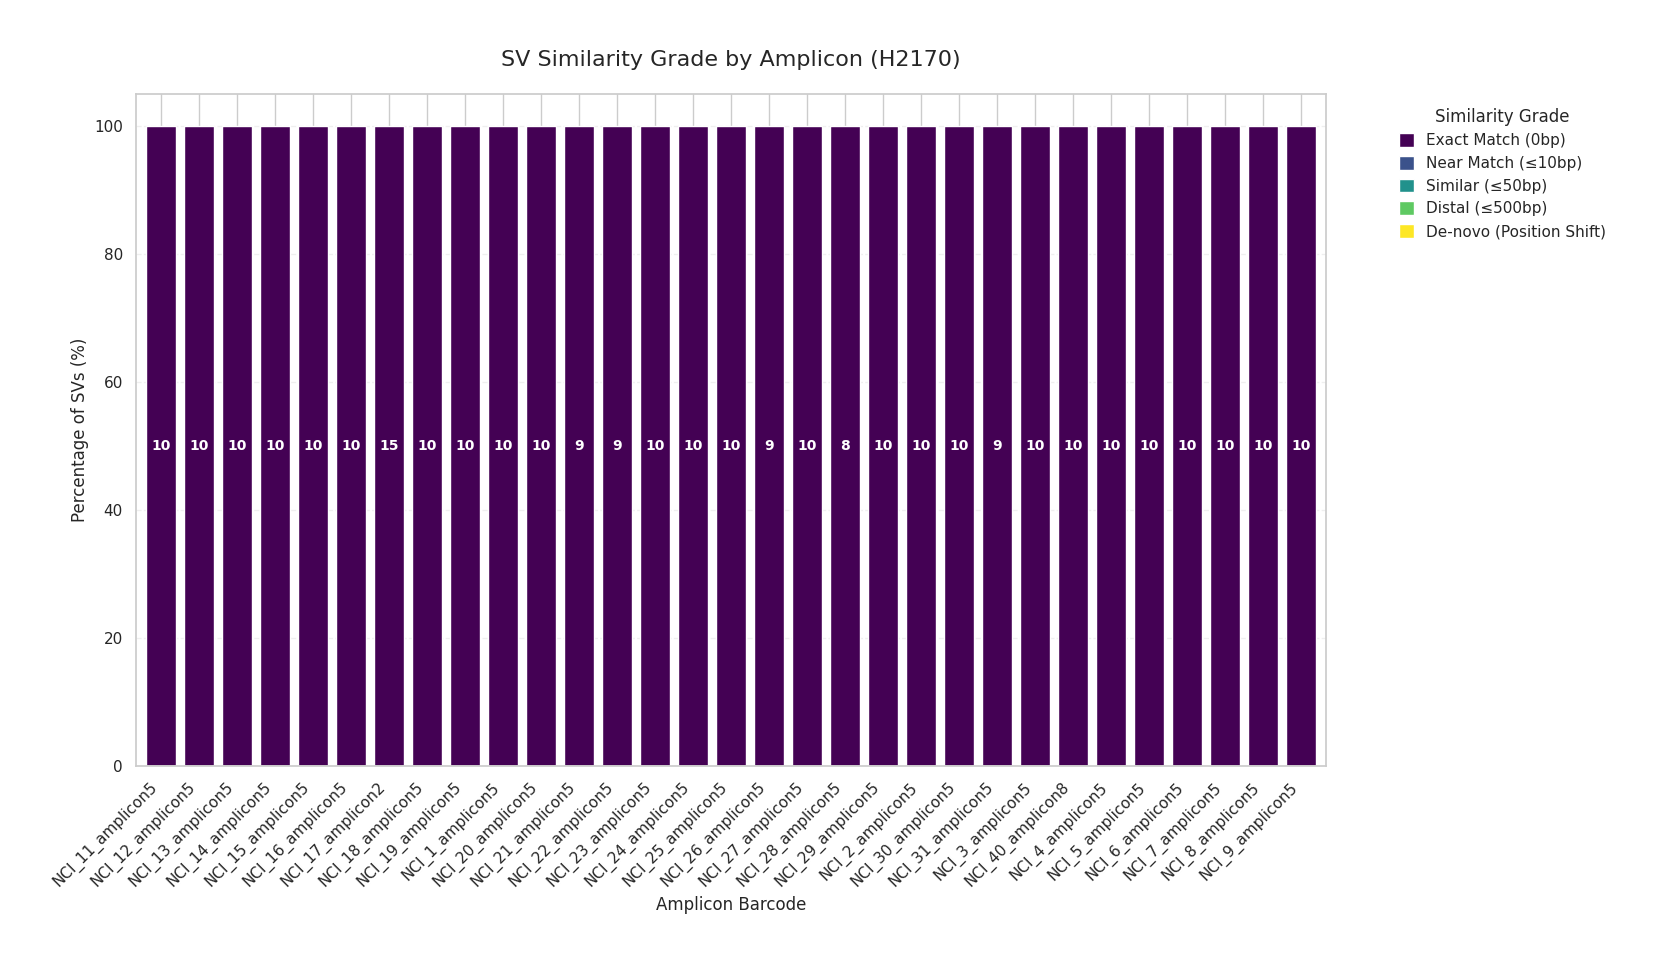

In [231]:
plot_df.head()
plot_df['sample_amp']=plot_df['sample_id']+'_'+plot_df['amplicon_number']

# 1. 분석 대상 샘플 필터링 (EFM_11)
target_df =plot_df.copy()

# 2. 분석 순서(Grade) 고정
order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)", "De-novo (Position Shift)"]

# 3. 개수(Count)와 비율(Percentage) 데이터 생성
pivot_df = target_df.groupby(['sample_amp', 'similarity_grade']).size().unstack(fill_value=0)
# 없는 등급은 0으로 채우고 순서 정렬
for col in order:
    if col not in pivot_df.columns:
        pivot_df[col] = 0
pivot_df = pivot_df[order]

# 비율 계산 (%)
pivot_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 4. 시각화
fig, ax = plt.subplots(figsize=(16, 9))
pivot_perc.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='white', width=0.8)

# 5. 막대 안에 실제 개수(Count) 써주기
for i, (name, row) in enumerate(pivot_perc.iterrows()):
    cumulative_height = 0
    for col in order:
        perc_val = row[col]
        count_val = pivot_df.loc[name, col]
        
        if count_val > 0:  # 데이터가 있는 경우에만 텍스트 표시
            # 텍스트 위치 계산 (각 누적 영역의 정중앙)
            pos_y = cumulative_height + (perc_val / 2)
            ax.text(i, pos_y, f'{int(count_val)}', 
                    ha='center', va='center', color='white', 
                    fontweight='bold', fontsize=10)
        
        cumulative_height += perc_val

# 6. 스타일링
plt.title(f'SV Similarity Grade by Amplicon ({source})', fontsize=16, pad=20)
plt.xlabel('Amplicon Barcode', fontsize=12)
plt.ylabel('Percentage of SVs (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # 바코드 이름이 길면 45도 기울임
plt.legend(title='Similarity Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# plt.savefig('sv_distribution_with_counts.png', dpi=300)
plt.show()

<ipython-input-219-f01e8f03cd41>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sv_merged['pos1_bin'] = (df_sv_merged['pos1'] // bin_size) * bin_size
<ipython-input-219-f01e8f03cd41>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sv_merged['pos2_bin'] = (df_sv_merged['pos2'] // bin_size) * bin_size
<ipython-input-219-f01e8f03cd41>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

<Figure size 1200x1000 with 0 Axes>

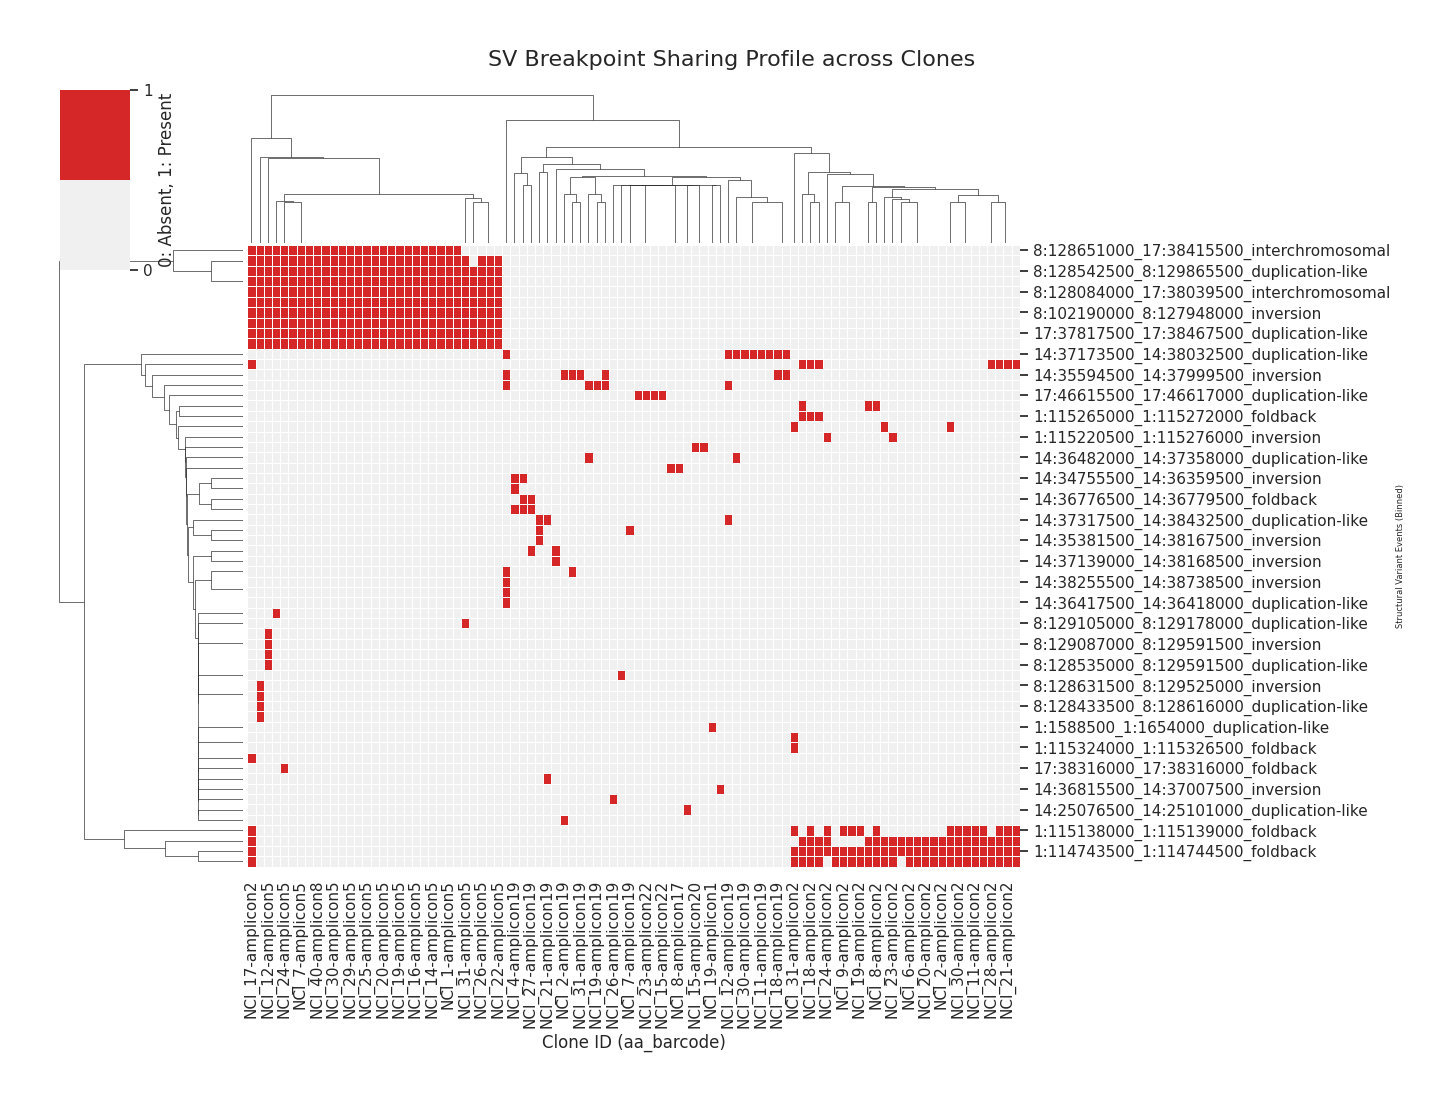

In [219]:
# df_sv_merged = aa_SV_sub.copy()
# 
# df_sv_merged = aa_SV_sub[(aa_SV_sub['amplicon_barcode'].isin(amp_barcode_ERBB2))]
df_sv_merged = aa_SV_sub[(aa_SV_sub['sample_id']!='parental')]


# 1. SV Binning (오차 허용 묶기)
# Breakpoint 호출 시 툴마다/샘플마다 미세한 오차가 발생하므로, 
# 500bp 단위로 위치를 반내림하여 같은 '구역(Bin)'에 있으면 동일한 SV로 간주합니다.
bin_size = 500 

df_sv_merged['pos1_bin'] = (df_sv_merged['pos1'] // bin_size) * bin_size
df_sv_merged['pos2_bin'] = (df_sv_merged['pos2'] // bin_size) * bin_size

# 고유한 SV 그룹 ID 생성 (예: chr17:38000000_chr8:102000000_BND)
df_sv_merged['SV_Group'] = (
    df_sv_merged['chrom1'].astype(str) + ":" + df_sv_merged['pos1_bin'].astype(str) + "_" +
    df_sv_merged['chrom2'].astype(str) + ":" + df_sv_merged['pos2_bin'].astype(str) + "_" +
    df_sv_merged['sv_type'].astype(str)
)

# 2. Presence/Absence Matrix 생성
# 해당 SV가 특정 샘플에 존재하면 1, 아니면 0을 부여합니다.
df_sv_merged['Presence'] = 1

# 중복 제거 (같은 샘플 내에서 같은 Bin에 들어간 SV가 여러 개 호출됐을 경우 하나로 침)
df_unique = df_sv_merged.drop_duplicates(subset=['aa_barcode', 'SV_Group'])

# Pivot Table 구성 (Row: SV Group, Column: Sample, Value: Presence)
sv_matrix = df_unique.pivot(index='SV_Group', columns='sample_amp', values='Presence').fillna(0)

# 💡 선택 사항: 너무 희귀한 SV(딱 한 클론에만 있는 Private SV)는 노이즈일 수 있으므로 제거 (2개 이상의 샘플에서 공유된 것만 보기)
# sv_matrix = sv_matrix[sv_matrix.sum(axis=1) >= 2]

# 3. Heatmap 그리기 (Clustermap 적용)
plt.figure(figsize=(12, 10))

# 클러스터링을 통해 비슷한 SV 패턴을 가진 클론들끼리, 
# 그리고 같이 움직이는 SV들끼리 모아줍니다.
cg = sns.clustermap(
    sv_matrix, 
    cmap=['#f0f0f0', '#d62728'], # 0은 밝은 회색, 1은 강렬한 빨간색
    figsize=(14, 10),
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'ticks': [0, 1], 'label': '0: Absent, 1: Present'}
)

cg.fig.suptitle('SV Breakpoint Sharing Profile across Clones', y=1.02, fontsize=16)
cg.ax_heatmap.set_xlabel('Clone ID (aa_barcode)', fontsize=12)
cg.ax_heatmap.set_ylabel('Structural Variant Events (Binned)', fontsize=6)

plt.show()

<ipython-input-220-c8942a2552eb>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sv_merged['pos1_bin'] = (df_sv_merged['pos1'] // bin_size) * bin_size
<ipython-input-220-c8942a2552eb>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sv_merged['pos2_bin'] = (df_sv_merged['pos2'] // bin_size) * bin_size
<ipython-input-220-c8942a2552eb>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

<Figure size 1200x1000 with 0 Axes>

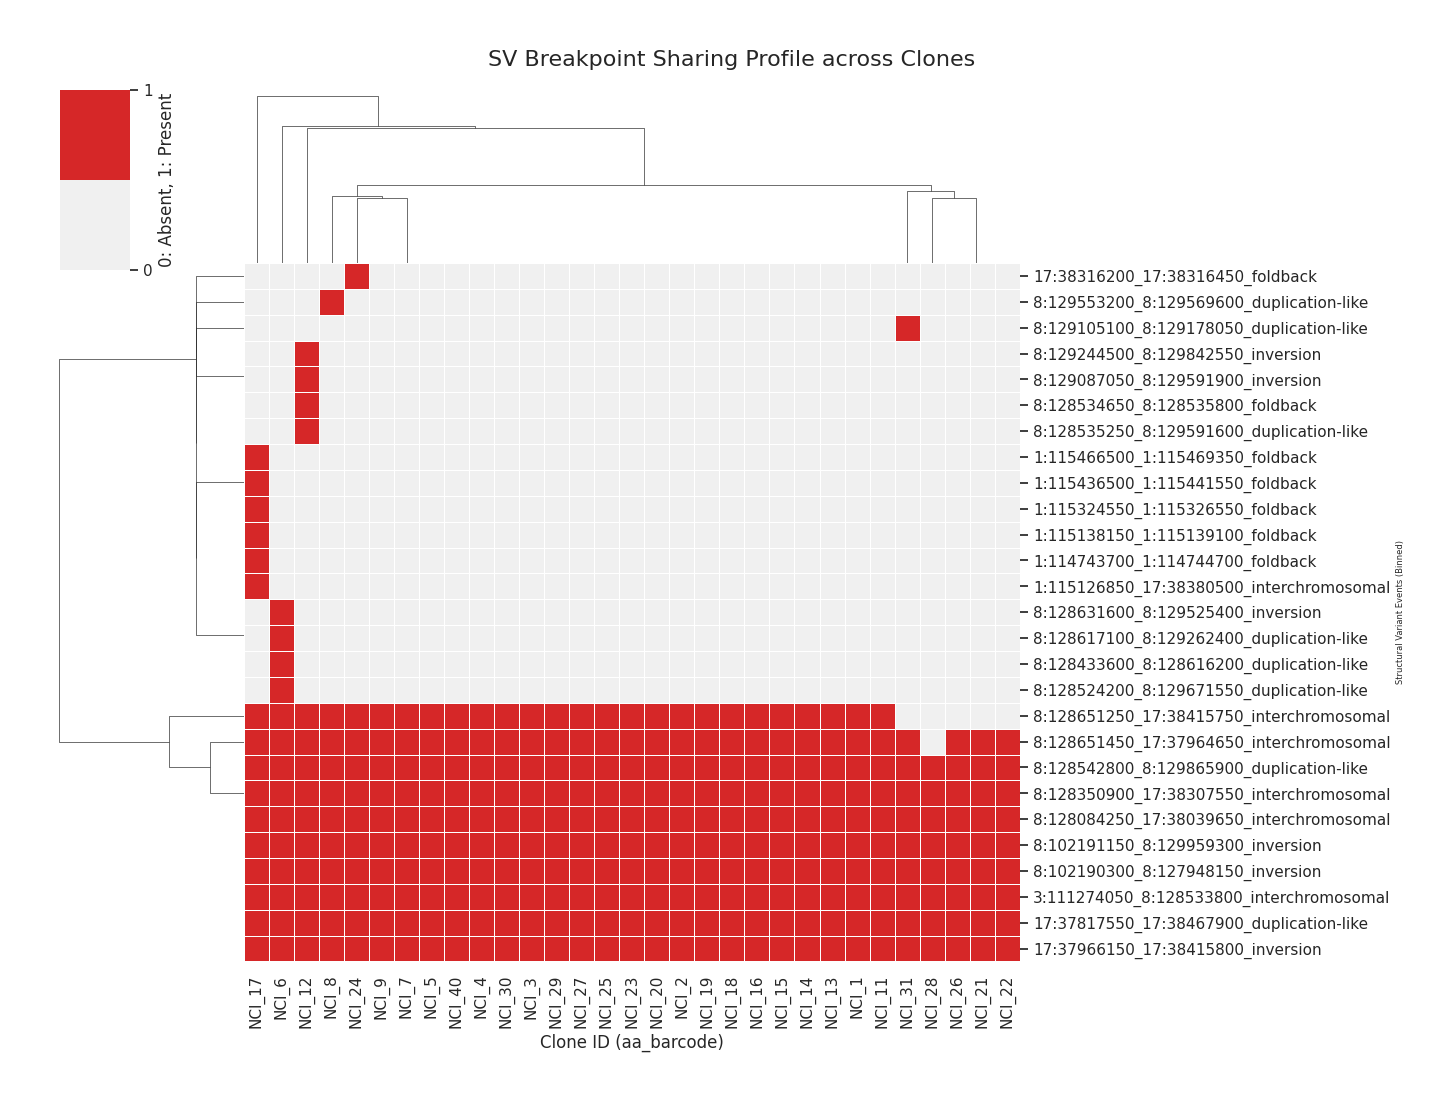

In [220]:
# df_sv_merged = aa_SV_sub.copy()
# df_sv_merged = aa_SV_sub[(aa_SV_sub['amplicon_barcode'].isin(amp_barcode_ERBB2))]
# df_sv_merged = aa_SV_sub[(aa_SV_sub['sample_id']!='parental')]
df_sv_merged = aa_SV_sub[(aa_SV_sub['amplicon_barcode'].isin(amp_barcode_ERBB2))&(aa_SV_sub['sample_id']!='parental')]


# 1. SV Binning (오차 허용 묶기)
# 500bp 단위로 위치를 반내림하여 같은 '구역(Bin)'에 있으면 동일한 SV로 간주합니다.
bin_size = 50 

df_sv_merged['pos1_bin'] = (df_sv_merged['pos1'] // bin_size) * bin_size
df_sv_merged['pos2_bin'] = (df_sv_merged['pos2'] // bin_size) * bin_size

# 고유한 SV 그룹 ID 생성 (예: chr17:38000000_chr8:102000000_BND)
df_sv_merged['SV_Group'] = (
    df_sv_merged['chrom1'].astype(str) + ":" + df_sv_merged['pos1_bin'].astype(str) + "_" +
    df_sv_merged['chrom2'].astype(str) + ":" + df_sv_merged['pos2_bin'].astype(str) + "_" +
    df_sv_merged['sv_type'].astype(str)
)

# 2. Presence/Absence Matrix 생성
# 해당 SV가 특정 샘플에 존재하면 1, 아니면 0을 부여합니다.
df_sv_merged['Presence'] = 1

# 중복 제거 (같은 샘플 내에서 같은 Bin에 들어간 SV가 여러 개 호출됐을 경우 하나로 침)
df_unique = df_sv_merged.drop_duplicates(subset=['sample_id', 'SV_Group'])

# Pivot Table 구성 (Row: SV Group, Column: Sample, Value: Presence)
sv_matrix = df_unique.pivot(index='SV_Group', columns='sample_id', values='Presence').fillna(0)

# 💡 선택 사항: 너무 희귀한 SV(딱 한 클론에만 있는 Private SV)는 노이즈일 수 있으므로 제거 (2개 이상의 샘플에서 공유된 것만 보기)
# sv_matrix = sv_matrix[sv_matrix.sum(axis=1) >= 2]

# 3. Heatmap 그리기 (Clustermap 적용)
plt.figure(figsize=(12, 10))

# 클러스터링을 통해 비슷한 SV 패턴을 가진 클론들끼리, 
# 그리고 같이 움직이는 SV들끼리 모아줍니다.
cg = sns.clustermap(
    sv_matrix, 
    cmap=['#f0f0f0', '#d62728'], # 0은 밝은 회색, 1은 강렬한 빨간색
    figsize=(14, 10),
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'ticks': [0, 1], 'label': '0: Absent, 1: Present'}
)

cg.fig.suptitle('SV Breakpoint Sharing Profile across Clones', y=1.02, fontsize=16)
cg.ax_heatmap.set_xlabel('Clone ID (aa_barcode)', fontsize=12)
cg.ax_heatmap.set_ylabel('Structural Variant Events (Binned)', fontsize=6)

plt.show()

In [90]:
# parental에는 있었는데 clone에서는 사라진 SV가 아주 많음 
# ERBB2가 포함된 amplicon만 봤을때는 clone이 확실히 복잡도가 낮음 (앞부분 적용됨)
# parental없이 clone만 비교해도 shared SV , privae SV 가 있음.
# ERBB2 & !parental의 경우에는 

In [221]:
# sv_matrix

In [222]:
df = test_sv.copy()

# 1. Breakpoint 위치 Binning (오차 500bp 허용)
bin_size = 500
df['pos1_bin'] = (df['pos1'] // bin_size) * bin_size
df['pos2_bin'] = (df['pos2'] // bin_size) * bin_size

df['SV_Group'] = (
    df['chrom1'].astype(str) + ":" + df['pos1_bin'].astype(str) + "_" +
    df['chrom2'].astype(str) + ":" + df['pos2_bin'].astype(str) + "_" +
    df['sv_type'].astype(str)
)

# 2. 단일 절단점(Breakend) 고유 ID 생성 (예: chr17:38000000)
df['bnd1_id'] = df['chrom1'].astype(str) + ":" + df['pos1_bin'].astype(str)
df['bnd2_id'] = df['chrom2'].astype(str) + ":" + df['pos2_bin'].astype(str)

# 3. 데이터셋 전체에서 각 Breakend가 '몇 개의 서로 다른 클론'에서 쓰였는지 카운트
# (Exact Match를 포함해서 전체 풀에서 세어야, Parental/다른 클론과 공유되는지 정확히 알 수 있습니다)
bnd_clones = {}
for idx, row in df.iterrows():
    clone = row['sample_id']
    bnd1 = row['bnd1_id']
    bnd2 = row['bnd2_id']
    
    if bnd1 not in bnd_clones: bnd_clones[bnd1] = set()
    bnd_clones[bnd1].add(clone)
    
    if bnd2 not in bnd_clones: bnd_clones[bnd2] = set()
    bnd_clones[bnd2].add(clone)

# 딕셔너리: { 'chr17:38000000' : 5 (5개 클론이 공유), ... }
bnd_freq = {k: len(v) for k, v in bnd_clones.items()}

# 4. Breakend 기반 진화 상태 주석 함수
def annotate_breakend_evolution(row):
    # Parental에서 그대로 온 완벽한 뼈대
    if row['similarity_grade'] == 'Exact Match (0bp)':
        return "Parental Origin (Trunk Pair)"
        
    # 각각의 Breakend가 몇 개의 클론에서 발견되는지 확인
    f1 = bnd_freq.get(row['bnd1_id'], 1)
    f2 = bnd_freq.get(row['bnd2_id'], 1)
    
    # 두 끝점이 모두 2개 이상의 클론에서 공유됨 (완전한 공통 가지)
    if f1 >= 2 and f2 >= 2:
        return "Shared Pair (Both ends common)"
        
    # 박사님이 짚어주신 핵심 포인트! 한쪽만 공통이고 다른 쪽은 새로 생김
    elif f1 >= 2 or f2 >= 2:
        return "Anchored Private (One common, one private)"
        
    # 양쪽 끝점이 모두 이 클론에만 존재하는 완전 새로운 변이
    else:
        return "Truly Private Pair (Both novel)"

# 5. 새로운 컬럼 적용
df['bnd_evolution_status'] = df.apply(annotate_breakend_evolution, axis=1)

# 결과 요약 확인
print("=== Breakend 기반 Clonal Evolution Status 요약 ===")
print(df['bnd_evolution_status'].value_counts())

=== Breakend 기반 Clonal Evolution Status 요약 ===
bnd_evolution_status
Parental Origin (Trunk Pair)                  437
Shared Pair (Both ends common)                 33
Truly Private Pair (Both novel)                22
Anchored Private (One common, one private)      1
Name: count, dtype: int64


In [223]:
# 1. SV 쌍(Pair) 전체를 공유하는 클론 목록 딕셔너리 만들기
# (같은 SV_Group을 가진 sample_id들을 집합(set)으로 묶어줍니다)
sv_clones_dict = df.groupby('SV_Group')['sample_id'].apply(set).to_dict()

# (참고: bnd_clones 딕셔너리는 이전 코드에서 이미 만들어졌다고 가정합니다. 
# 만약 없다면 이전 코드의 3번 스텝을 먼저 실행해 주세요!)

# 2. 맵핑된 샘플 ID를 추출하는 함수 정의
def get_mapped_samples(row):
    current_sample = row['sample_id']
    
    # 본인(current_sample)을 제외한 나머지 클론들만 교집합에서 빼냅니다 (-)
    
    # 1) 전체 SV 쌍을 똑같이 가진 클론들
    sv_match = sv_clones_dict.get(row['SV_Group'], set()) - {current_sample}
    
    # 2) 왼쪽 절단점(pos1)만 똑같이 가진 클론들
    bnd1_match = bnd_clones.get(row['bnd1_id'], set()) - {current_sample}
    
    # 3) 오른쪽 절단점(pos2)만 똑같이 가진 클론들
    bnd2_match = bnd_clones.get(row['bnd2_id'], set()) - {current_sample}
    
    # 리스트를 보기 좋게 문자열로 변환 (아무도 없으면 'None'으로 표기)
    sv_mapped = ", ".join(sorted(sv_match)) if sv_match else "None"
    bnd1_mapped = ", ".join(sorted(bnd1_match)) if bnd1_match else "None"
    bnd2_mapped = ", ".join(sorted(bnd2_match)) if bnd2_match else "None"
    
    return pd.Series([sv_mapped, bnd1_mapped, bnd2_mapped])

# 3. 데이터프레임에 3개의 새로운 컬럼으로 적용
df[['mapped_SV_clones', 'mapped_bnd1_clones', 'mapped_bnd2_clones']] = df.apply(get_mapped_samples, axis=1)

df.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade,log10_d1,log10_d2,pos1_bin,pos2_bin,SV_Group,bnd1_id,bnd2_id,bnd_evolution_status,mapped_SV_clones,mapped_bnd1_clones,mapped_bnd2_clones
406,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,35581234,14,40323254,duplication-like,2,ecDNA,-+,35581235,40323253,-1.0,A,H2170,NCI_9,ecDNA,NCI_9-amplicon19,0.0,0.0,0.0,Exact Match (0bp),0.000000,0.000000,35581000,40323000,14:35581000_14:40323000_duplication-like,14:35581000,14:40323000,Parental Origin (Trunk Pair),"NCI_12, NCI_19, NCI_28, NCI_3","NCI_12, NCI_19, NCI_28, NCI_3","NCI_12, NCI_19, NCI_28, NCI_3"
407,ECTRES-H2170-0001-TPX-A09-WGS-6XP120_amplicon19,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,amplicon19,14,36482109,14,37358131,duplication-like,3,ecDNA,-+,36482110,37358130,2.0,CC,H2170,NCI_9,ecDNA,NCI_9-amplicon19,11615.0,573974.0,573974.0,De-novo (Both shifted),4.065057,5.758893,36482000,37358000,14:36482000_14:37358000_duplication-like,14:36482000,14:37358000,Shared Pair (Both ends common),NCI_5,NCI_5,NCI_5


In [224]:
df[df['bnd_evolution_status']=='Anchored Private (One common, one private)']

# df[df['bnd_evolution_status']=='Truly Private Pair (Both novel)']


,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade,log10_d1,log10_d2,pos1_bin,pos2_bin,SV_Group,bnd1_id,bnd2_id,bnd_evolution_status,mapped_SV_clones,mapped_bnd1_clones,mapped_bnd2_clones
876,ECTRES-H2170-0001-TPX-A31-WGS-VZD4GS_amplicon2,ECTRES-H2170-0001-TPX-A31-WGS-VZD4GS,amplicon2,1,115324439,1,115326567,foldback,3,BFB,++,115324438,115326566,NaN,NaN,H2170,NCI_31,BFB,NCI_31-amplicon2,121.0,0.0,121.0,"Anchored Distal (One end 0bp, One end ≤500bp)",2.08636,0.0,115324000,115326500,1:115324000_1:115326500_foldback,1:115324000,1:115326500,"Anchored Private (One common, one private)",None,None,"NCI_1, NCI_11, NCI_12, NCI_13, NCI_15, NCI_16,..."


In [229]:
df['bnd_evolution_status'].value_counts()

bnd_evolution_status
Parental Origin (Trunk Pair)                  437
Shared Pair (Both ends common)                 33
Truly Private Pair (Both novel)                22
Anchored Private (One common, one private)      1
Name: count, dtype: int64

In [225]:
# !pip install pycirclize

In [226]:
from pycirclize import Circos
from pycirclize.utils import load_eukaryote_example_dataset
import matplotlib.pyplot as plt
import matplotlib.colors as mc

# 1. hg19 데이터셋 로드 (박사님 레퍼런스에 맞춤)
chr_bed_file, cytoband_file, _ = load_eukaryote_example_dataset("hg19")

# Circos 초기화 (염색체 뼈대 만들기)
circos = Circos.initialize_from_bed(chr_bed_file, space=3)
circos.text("EFM19 Clones\n(hg19)", deg=315, r=150, size=14, fontweight='bold')

# Cytoband (염색체 밴드 무늬) 추가
circos.add_cytoband_tracks((95, 100), cytoband_file)

# 2. 염색체 텍스트 및 눈금선 그리기
for sector in circos.sectors:
    # 염색체 이름 (chr1, chr2 ...)
    sector.text(sector.name, r=115, size=9)
    # 50Mb 단위로 눈금 표시
    sector.get_track("cytoband").xticks_by_interval(
        50000000, 
        label_size=7, 
        label_orientation="vertical", 
        label_formatter=lambda v: f"{v / 1000000:.0f}M"
    )

# 3. 데이터 전처리 (chr 접두사 맞추기)
# pycirclize의 hg19는 'chr17' 형태를 쓰므로, test_sv에 'chr'이 없다면 붙여줍니다.
test_sv['chrom1_circos'] = test_sv['chrom1'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
test_sv['chrom2_circos'] = test_sv['chrom2'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))

# 4. 진화 상태(Evolution Status)에 따른 색상 딕셔너리
# 여기서 지정한 색상이 앰플리콘의 진화 역동성을 보여줍니다.
color_map = {
    "Parental Origin (Trunk Pair)": "#d3d3d3",   # 밝은 회색 (안정적인 뼈대 배경)
    "Shared Pair (Both ends common)": "#1f77b4", # 파란색 (공유 가지)
    "Anchored Private (One common, one private)": "#ff7f0e", # 주황색 (한쪽만 뻗어나간 탐색 변이)
    "Truly Private Pair (Both novel)": "#d62728" # 빨간색 (완전히 새로운 구조적 융합)
}

# 5. test_sv 데이터의 SV들을 Circos Link로 연결하기
# 너무 많은 선이 겹치지 않도록 투명도(alpha)를 조절합니다.
for idx, row in test_sv.iterrows():
    chr1 = row['chrom1_circos']
    pos1 = int(row['pos1'])
    chr2 = row['chrom2_circos']
    pos2 = int(row['pos2'])
    
    # 딕셔너리에 없으면 기본 검은색, 투명도 0.6 설정
    evo_status = row.get('bnd_evolution_status', 'Truly Private Pair (Both novel)')
    base_color = color_map.get(evo_status, "black")
    
    # matplotlib colors로 투명도 적용된 rgba 색상 생성
    rgb = mc.to_rgb(base_color)
    link_color = (*rgb, 0.5) # alpha 0.5 (반투명)
    
    # 두 구간 설정 (Breakpoint이므로 시작과 끝을 +1 bp 차이로 잡음)
    region1 = (chr1, pos1, pos1 + 1)
    region2 = (chr2, pos2, pos2 + 1)
    
    # 정의된 염색체(chr1~chr22, X, Y) 안에 있는 정상 좌표일 때만 그리기
    if chr1 in circos.sector_names and chr2 in circos.sector_names:
        circos.link(region1, region2, color=link_color)

# 6. 최종 이미지 출력
fig = circos.plotfig()
# 범례 추가를 위해 별도의 축 생성
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in color_map.values()]
fig.legend(handles, color_map.keys(), loc='center right', title='Evolution Status', fontsize=9)

plt.show()

ValueError: name='hg19' dataset not found.
available_dataset=['hg38', 'hs1', 'mm10', 'mm39']

[*] Successfully generated unzipped hg19 reference files!


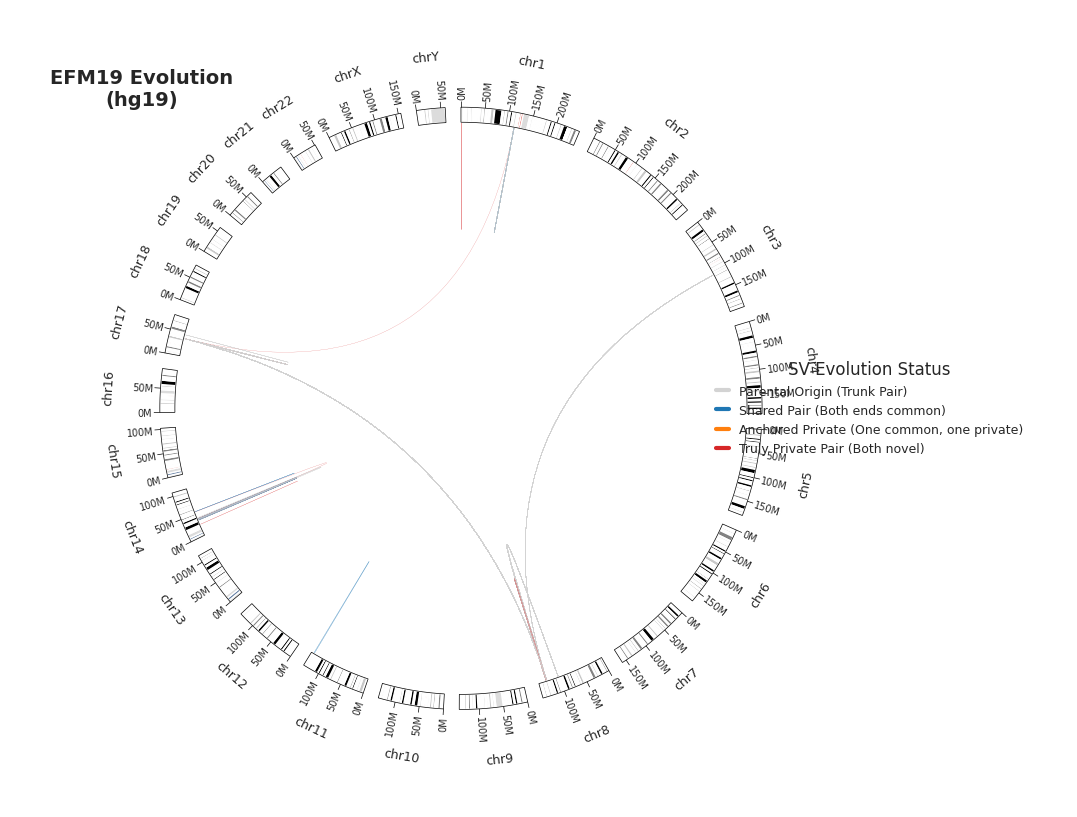

In [227]:
import pandas as pd
import urllib.request
import os
import gzip
import shutil
from pycirclize import Circos
import matplotlib.pyplot as plt
import matplotlib.colors as mc

# 1. UCSC 서버에서 hg19 cytoband 다운로드 및 압축 해제 (핵심 수정!)
url = "https://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/cytoBand.txt.gz"
gz_file = "hg19_cytoBand.txt.gz"
cytoband_file = "hg19_cytoBand.txt" # pycirclize가 읽을 압축 풀린 파일
bed_file = "hg19_chrom_sizes.bed"

# 파일이 없으면 다운로드 후 압축 해제
if not os.path.exists(cytoband_file):
    print("[*] Downloading hg19 cytoband data directly from UCSC...")
    urllib.request.urlretrieve(url, gz_file)
    
    print("[*] Unzipping the cytoBand file for pycirclize...")
    with gzip.open(gz_file, 'rb') as f_in:
        with open(cytoband_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

# 2. hg19 뼈대를 만들기 위해 BED 파일 자동 생성
# 이제 압축 풀린 txt 파일을 pandas로 읽습니다.
df_cyto = pd.read_csv(cytoband_file, sep="\t", header=None, names=["chrom", "start", "end", "name", "stain"])

# 1~22번, X, Y 염색체만 추출
standard_chrs = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
df_cyto = df_cyto[df_cyto["chrom"].isin(standard_chrs)]

# 염색체별 최대 길이 계산 후 BED 형식으로 저장
df_bed = df_cyto.groupby("chrom")["end"].max().reset_index()
df_bed.insert(1, "start", 0)
df_bed["chrom"] = pd.Categorical(df_bed["chrom"], categories=standard_chrs, ordered=True)
df_bed = df_bed.sort_values("chrom")
df_bed.to_csv(bed_file, sep="\t", index=False, header=False)

print("[*] Successfully generated unzipped hg19 reference files!")

# ==========================================
# 3. 여기서부터 본격적인 Circos Plot 시작 (이후 코드는 동일합니다)
# ==========================================
circos = Circos.initialize_from_bed(bed_file, space=3)
# ... (아래는 기존 코드 그대로 사용)
# ==========================================
# 3. 여기서부터 본격적인 Circos Plot 시작
# ==========================================
# 방금 만든 hg19 BED 파일로 뼈대 초기화
circos = Circos.initialize_from_bed(bed_file, space=3)
circos.text("EFM19 Evolution\n(hg19)", deg=315, r=150, size=14, fontweight='bold')

# 다운받은 cytoband 원본 파일을 그대로 트랙에 씌우기
circos.add_cytoband_tracks((95, 100), cytoband_file)

# 텍스트 및 눈금선 설정
for sector in circos.sectors:
    sector.text(sector.name, r=115, size=9)
    sector.get_track("cytoband").xticks_by_interval(
        50000000, 
        label_size=7, 
        label_orientation="vertical", 
        label_formatter=lambda v: f"{v / 1000000:.0f}M"
    )

# 4. 진화 상태(Evolution Status)에 따른 색상 딕셔너리
color_map = {
    "Parental Origin (Trunk Pair)": "#d3d3d3",   # 밝은 회색 (안정적 뼈대)
    "Shared Pair (Both ends common)": "#1f77b4", # 파란색 (공유 가지)
    "Anchored Private (One common, one private)": "#ff7f0e", # 주황색 (한쪽만 탐색)
    "Truly Private Pair (Both novel)": "#d62728" # 빨간색 (신규 변이)
}

# 5. SV 데이터 연결 (Link)
# pycirclize는 'chr17' 포맷을 원하므로 접두사를 맞춰줍니다.
test_sv = df.copy()

# ==========================================
# 5. SV 데이터 연결 (Link)
# ==========================================
test_sv['chrom1_circos'] = test_sv['chrom1'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
test_sv['chrom2_circos'] = test_sv['chrom2'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
# 💡 수정된 부분: circos 객체 안에 생성된 염색체 이름들을 리스트로 직접 추출합니다.
valid_chrs = [s.name for s in circos.sectors]

for idx, row in test_sv.iterrows():
    chr1 = row['chrom1_circos']
    pos1 = int(row['pos1'])
    chr2 = row['chrom2_circos']
    pos2 = int(row['pos2'])
    
    evo_status = row.get('bnd_evolution_status', 'Truly Private Pair (Both novel)')
    base_color = color_map.get(evo_status, "black")
    
    rgb = mc.to_rgb(base_color)
    link_color = (*rgb, 0.5) 
    
    region1 = (chr1, pos1, pos1 + 1)
    region2 = (chr2, pos2, pos2 + 1)
    
    # 💡 수정된 부분: 추출해둔 valid_chrs 리스트와 비교합니다.
    if chr1 in valid_chrs and chr2 in valid_chrs:
        circos.link(region1, region2, color=link_color)

# 6. 최종 이미지 출력
fig = circos.plotfig()

# 범례 추가
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in color_map.values()]
fig.legend(handles, color_map.keys(), loc='center right', bbox_to_anchor=(1.25, 0.5), title='SV Evolution Status', fontsize=9)

plt.show()

In [119]:
test_sv['bnd_evolution_status'].value_counts()

bnd_evolution_status
Parental Origin (Trunk Pair)                  392
Shared Pair (Both ends common)                 66
Truly Private Pair (Both novel)                28
Anchored Private (One common, one private)     15
Name: count, dtype: int64

[*] Plotted Chromosomes (6개): chr1, chr3, chr8, chr11, chr14, chr17


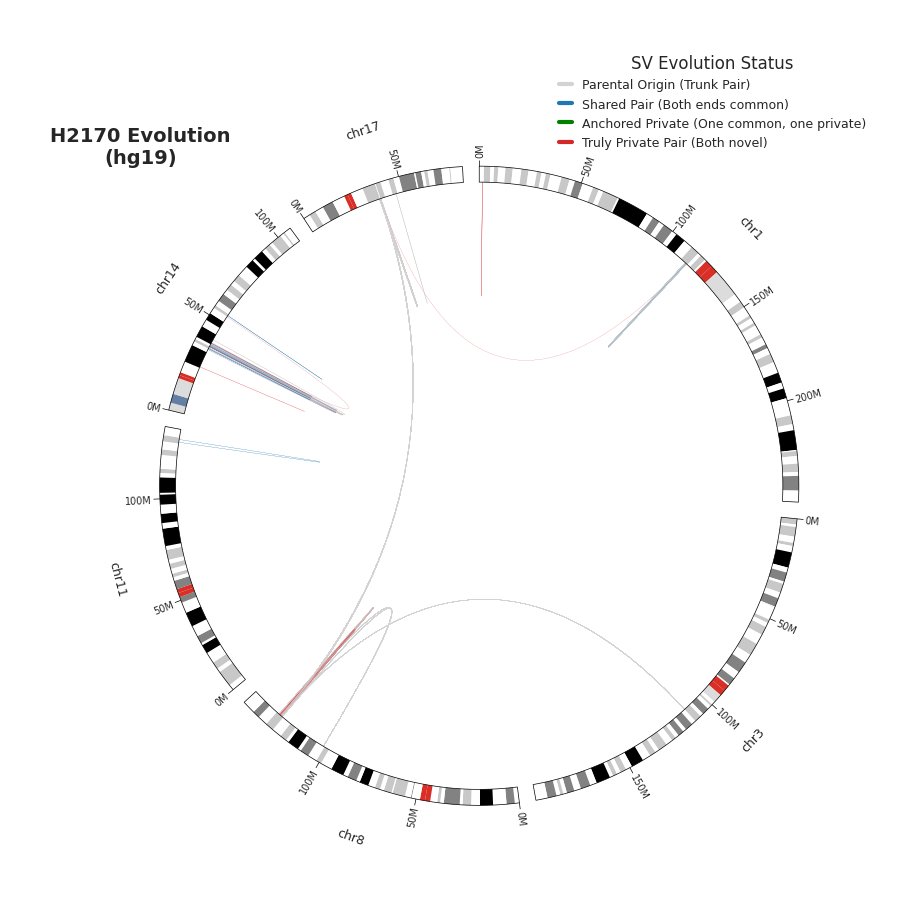

In [96]:
# ==========================================
# 2. SV가 존재하는 Unique 염색체만 추출하여 BED 생성
# ==========================================
# pycirclize 양식에 맞게 'chr' 접두사가 붙은 임시 컬럼을 먼저 생성합니다.
test_sv['chrom1_circos'] = test_sv['chrom1'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
test_sv['chrom2_circos'] = test_sv['chrom2'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))

# 데이터셋에 존재하는 모든 고유 염색체 목록 추출 (교집합 + 합집합)
unique_chrs = set(test_sv['chrom1_circos']).union(set(test_sv['chrom2_circos']))

# 1~22, X, Y 순서를 예쁘게 유지하기 위해 standard 리스트와 교집합을 구합니다.
standard_chrs = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
target_chrs = [chrom for chrom in standard_chrs if chrom in unique_chrs]

print(f"[*] Plotted Chromosomes ({len(target_chrs)}개): {', '.join(target_chrs)}")

# cytoband 파일에서 타겟 염색체만 필터링
df_cyto = pd.read_csv(cytoband_file, sep="\t", header=None, names=["chrom", "start", "end", "name", "stain"])
df_cyto = df_cyto[df_cyto["chrom"].isin(target_chrs)]

# 염색체별 최대 길이 계산 후 BED 형식으로 저장
df_bed = df_cyto.groupby("chrom")["end"].max().reset_index()
df_bed.insert(1, "start", 0)
df_bed["chrom"] = pd.Categorical(df_bed["chrom"], categories=target_chrs, ordered=True)
df_bed = df_bed.sort_values("chrom")
df_bed.to_csv(bed_file, sep="\t", index=False, header=False)

# ==========================================
# 3. Circos Plot 시작
# ==========================================
# 방금 만든 hg19 BED 파일로 뼈대 초기화
circos = Circos.initialize_from_bed(bed_file, space=3)
circos.text(f"{source} Evolution\n(hg19)", deg=315, r=150, size=14, fontweight='bold')

# 다운받은 cytoband 원본 파일을 그대로 트랙에 씌우기
circos.add_cytoband_tracks((95, 100), cytoband_file)

# 텍스트 및 눈금선 설정
for sector in circos.sectors:
    sector.text(sector.name, r=115, size=9)
    sector.get_track("cytoband").xticks_by_interval(
        50000000, 
        label_size=7, 
        label_orientation="vertical", 
        label_formatter=lambda v: f"{v / 1000000:.0f}M"
    )

# 4. 진화 상태(Evolution Status)에 따른 색상 딕셔너리
color_map = {
    "Parental Origin (Trunk Pair)": "#d3d3d3",   # 밝은 회색 (안정적 뼈대)
    "Shared Pair (Both ends common)": "#1f77b4", # 파란색 (공유 가지)
    "Anchored Private (One common, one private)": "green", # 주황색 (한쪽만 탐색)
    "Truly Private Pair (Both novel)": "#d62728" # 빨간색 (신규 변이)
}

# 5. SV 데이터 연결 (Link)
# pycirclize는 'chr17' 포맷을 원하므로 접두사를 맞춰줍니다.
test_sv = df.copy()

# ==========================================
# 5. SV 데이터 연결 (Link)
# ==========================================
test_sv['chrom1_circos'] = test_sv['chrom1'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
test_sv['chrom2_circos'] = test_sv['chrom2'].apply(lambda x: f"chr{x}" if not str(x).startswith("chr") else str(x))
# 💡 수정된 부분: circos 객체 안에 생성된 염색체 이름들을 리스트로 직접 추출합니다.
valid_chrs = [s.name for s in circos.sectors]

for idx, row in test_sv.iterrows():
    chr1 = row['chrom1_circos']
    pos1 = int(row['pos1'])
    chr2 = row['chrom2_circos']
    pos2 = int(row['pos2'])
    
    evo_status = row.get('bnd_evolution_status', 'Truly Private Pair (Both novel)')
    base_color = color_map.get(evo_status, "black")
    
    rgb = mc.to_rgb(base_color)
    link_color = (*rgb, 0.5) 
    
    region1 = (chr1, pos1, pos1 + 1)
    region2 = (chr2, pos2, pos2 + 1)
    
    # 💡 수정된 부분: 추출해둔 valid_chrs 리스트와 비교합니다.
    if chr1 in valid_chrs and chr2 in valid_chrs:
        circos.link(region1, region2, color=link_color)

# 6. 최종 이미지 출력
fig = circos.plotfig()

# 범례 추가
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in color_map.values()]
fig.legend(handles, color_map.keys(), loc='upper right', bbox_to_anchor=(1.05, 1.05), title='SV Evolution Status', fontsize=9)

plt.show()

/home/jiwon/.local/lib/python3.9/site-packages/pycirclize/sector.py:159: UserWarning: r_lim=(100, 105) is unexpected plot range (0 <= r <= 100).
  warnings.warn(f"{r_lim=} is unexpected plot range (0 <= r <= 100).")
/home/jiwon/.local/lib/python3.9/site-packages/pycirclize/sector.py:159: UserWarning: r_lim=(105, 115) is unexpected plot range (0 <= r <= 100).
  warnings.warn(f"{r_lim=} is unexpected plot range (0 <= r <= 100).")


[*] Marked ERBB2 gene location at chr17:37,844,393-37,884,913


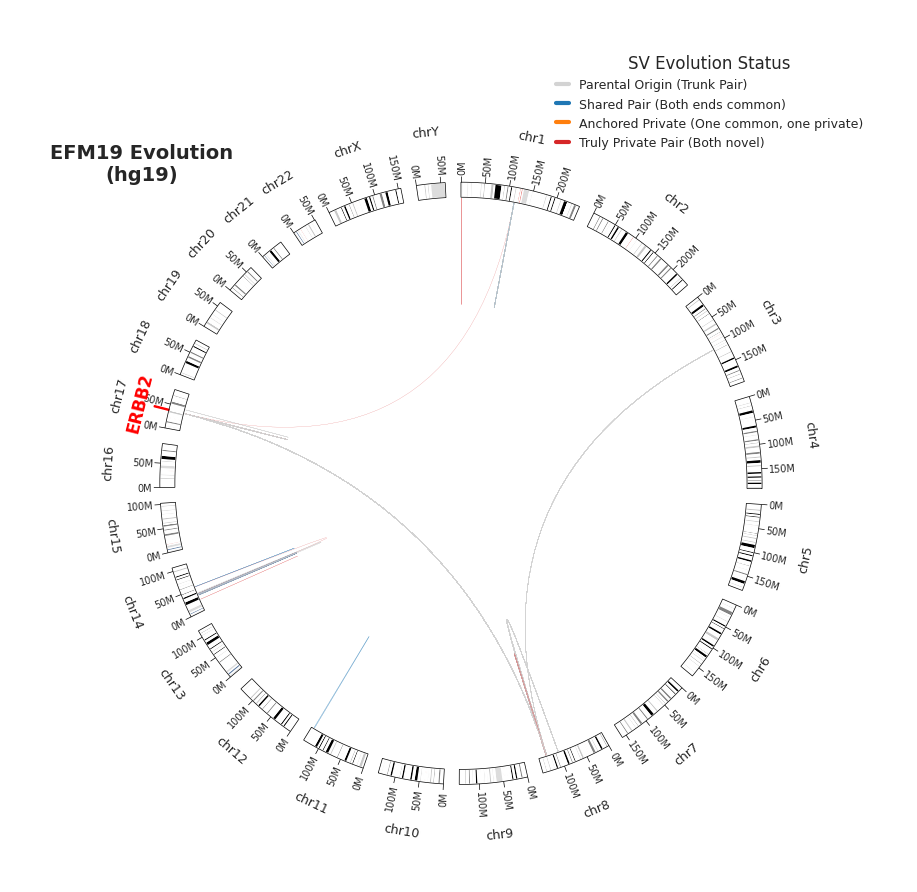

In [228]:
# ==========================================
# 6. ERBB2 유전자 위치 표기 (hg19)
# ==========================================
erbb2_chr = "chr17"
erbb2_start = 37844393  
erbb2_end = 37884913    

# 시각적으로 잘 보이도록 앞뒤로 1Mb씩 마커 너비 확장 (단순 표기용)
plot_start = max(0, erbb2_start - 1000000)
plot_end = erbb2_end + 1000000

# 도화지에 그려진 염색체 목록 가져오기
valid_chrs = [s.name for s in circos.sectors]

if erbb2_chr in valid_chrs:
    sector = circos.get_sector(erbb2_chr)
    
    # 1. 밴드(95~100) 바로 바깥쪽(100~105)에 얇은 '마커 전용 트랙'을 하나 추가합니다.
    marker_track = sector.add_track((100, 105))
    
    # 그 트랙의 해당 좌표에 빨간색 네모(rect)를 칠합니다.
    marker_track.rect(plot_start, plot_end, color="red")
    
    # 2. 글씨가 네모와 안 겹치도록 좀 더 바깥쪽(105~115)에 '텍스트 전용 트랙' 추가
    text_track = sector.add_track((105, 115))
    
    # 중앙 좌표(x)를 지정해서 글씨를 씁니다.
    text_track.text("ERBB2", x=(erbb2_start + erbb2_end) / 2, color="red", size=12, fontweight="bold")

print(f"[*] Marked ERBB2 gene location at {erbb2_chr}:{erbb2_start:,}-{erbb2_end:,}")

# ==========================================
# 7. 최종 이미지 출력
# ==========================================
fig = circos.plotfig()

handles = [plt.Line2D([0], [0], color=c, lw=3) for c in color_map.values()]
fig.legend(handles, color_map.keys(), loc='upper right', bbox_to_anchor=(1.05, 1.05), title='SV Evolution Status', fontsize=9)

plt.show()

In [126]:
df.head()

df[df['bnd_evolution_status']!='Parental Origin (Trunk Pair)']

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade,log10_d1,log10_d2,pos1_bin,pos2_bin,SV_Group,bnd1_id,bnd2_id,bnd_evolution_status,mapped_SV_clones,mapped_bnd1_clones,mapped_bnd2_clones
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN,EFM19,EFM_5,Linear,EFM_5-amplicon14,0.0,15.0,15.0,Similar (Both ≤50bp),0.000000,1.204120,45643500,45646000,20:45643500_20:45646000_foldback,20:45643500,20:45646000,Shared Pair (Both ends common),None,"EFM_1, EFM_11, EFM_3, EFM_7, EFM_9","EFM_3, EFM_7"
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN,EFM19,EFM_5,Linear,EFM_5-amplicon14,58.0,36.0,58.0,Distal (Both shifted ≤500bp),1.770852,1.568202,46843000,47214500,20:46843000_20:47214500_inversion,20:46843000,20:47214500,Shared Pair (Both ends common),"EFM_2, EFM_4, EFM_6, EFM_7, EFM_8","EFM_2, EFM_4, EFM_6, EFM_7, EFM_8","EFM_2, EFM_4, EFM_6, EFM_7, EFM_8"
4,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon2,1,57151411,8,117296688,interchromosomal,2,NaN,-+,57151412,117296687,NaN,NaN,EFM19,EFM_5,ecDNA,EFM_5-amplicon2,0.0,85.0,85.0,"Anchored Distal (One end 0bp, One end ≤500bp)",0.000000,1.934498,57151000,117296500,1:57151000_8:117296500_interchromosomal,1:57151000,8:117296500,Shared Pair (Both ends common),"EFM_3, EFM_7, EFM_8, EFM_9","EFM_3, EFM_7, EFM_8, EFM_9","EFM_3, EFM_7, EFM_8, EFM_9"
5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon2,1,57155207,8,125236771,interchromosomal,2,NaN,+-,57155206,125236772,NaN,NaN,EFM19,EFM_5,ecDNA,EFM_5-amplicon2,247108.0,1662054.0,1662054.0,De-novo (Both shifted),5.392889,6.220645,57155000,125236500,1:57155000_8:125236500_interchromosomal,1:57155000,8:125236500,Shared Pair (Both ends common),"EFM_3, EFM_6","EFM_11, EFM_2, EFM_3, EFM_6, EFM_7","EFM_3, EFM_6"
7,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon2,8,81088002,8,85395969,duplication-like,3,unknown,-+,81088003,85395968,NaN,NaN,EFM19,EFM_5,ecDNA,EFM_5-amplicon2,3816672.0,10083.0,3816672.0,De-novo (Both shifted),6.581685,4.003633,81088000,85395500,8:81088000_8:85395500_duplication-like,8:81088000,8:85395500,Shared Pair (Both ends common),None,"EFM_11, EFM_2, EFM_7, EFM_9","EFM_1, EFM_11, EFM_2, EFM_6, EFM_7, EFM_9"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon2,8,117481543,8,126519079,duplication-like,4,ecDNA,-+,117481544,126519078,NaN,NaN,EFM19,EFM_8,ecDNA,EFM_8-amplicon2,0.0,1.0,1.0,Near Match (≤10bp),0.000000,0.301030,117481500,126519000,8:117481500_8:126519000_duplication-like,8:117481500,8:126519000,Shared Pair (Both ends common),"EFM_1, EFM_11, EFM_2, EFM_4, EFM_5, EFM_7, EFM_9","EFM_1, EFM_11, EFM_2, EFM_4, EFM_5, EFM_7, EFM_9","EFM_1, EFM_11, EFM_2, EFM_4, EFM_5, EFM_7, EFM_9"
961,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,12,32354480,12,32491105,duplication-like,2,Complex-non-cyclic,-+,32354481,32491104,NaN,NaN,EFM19,EFM_8,CNC,EFM_8-amplicon8,0.0,152.0,152.0,"Anchored Distal (One end 0bp, One end ≤500bp)",0.000000,2.184691,32354000,32491000,12:32354000_12:32491000_duplication-like,12:32354000,12:32491000,Shared Pair (Both ends common),"EFM_1, EFM_11, EFM_2, EFM_3, EFM_4, EFM_5, EFM...","EFM_1, EFM_11, EFM_2, EFM_3, EFM_4, EFM_5, EFM...","EFM_1, EFM_11, EFM_2, EFM_3, EFM_4, EFM_5, EFM..."
970,ECTRES-EFM19-

In [127]:
df.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,sample_amp,dist_pos1,dist_pos2,max_dist,similarity_grade,log10_d1,log10_d2,pos1_bin,pos2_bin,SV_Group,bnd1_id,bnd2_id,bnd_evolution_status,mapped_SV_clones,mapped_bnd1_clones,mapped_bnd2_clones
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN,EFM19,EFM_5,Linear,EFM_5-amplicon14,0.0,15.0,15.0,Similar (Both ≤50bp),0.000000,1.204120,45643500,45646000,20:45643500_20:45646000_foldback,20:45643500,20:45646000,Shared Pair (Both ends common),None,"EFM_1, EFM_11, EFM_3, EFM_7, EFM_9","EFM_3, EFM_7"
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN,EFM19,EFM_5,Linear,EFM_5-amplicon14,58.0,36.0,58.0,Distal (Both shifted ≤500bp),1.770852,1.568202,46843000,47214500,20:46843000_20:47214500_inversion,20:46843000,20:47214500,Shared Pair (Both ends common),"EFM_2, EFM_4, EFM_6, EFM_7, EFM_8","EFM_2, EFM_4, EFM_6, EFM_7, EFM_8","EFM_2, EFM_4, EFM_6, EFM_7, EFM_8"


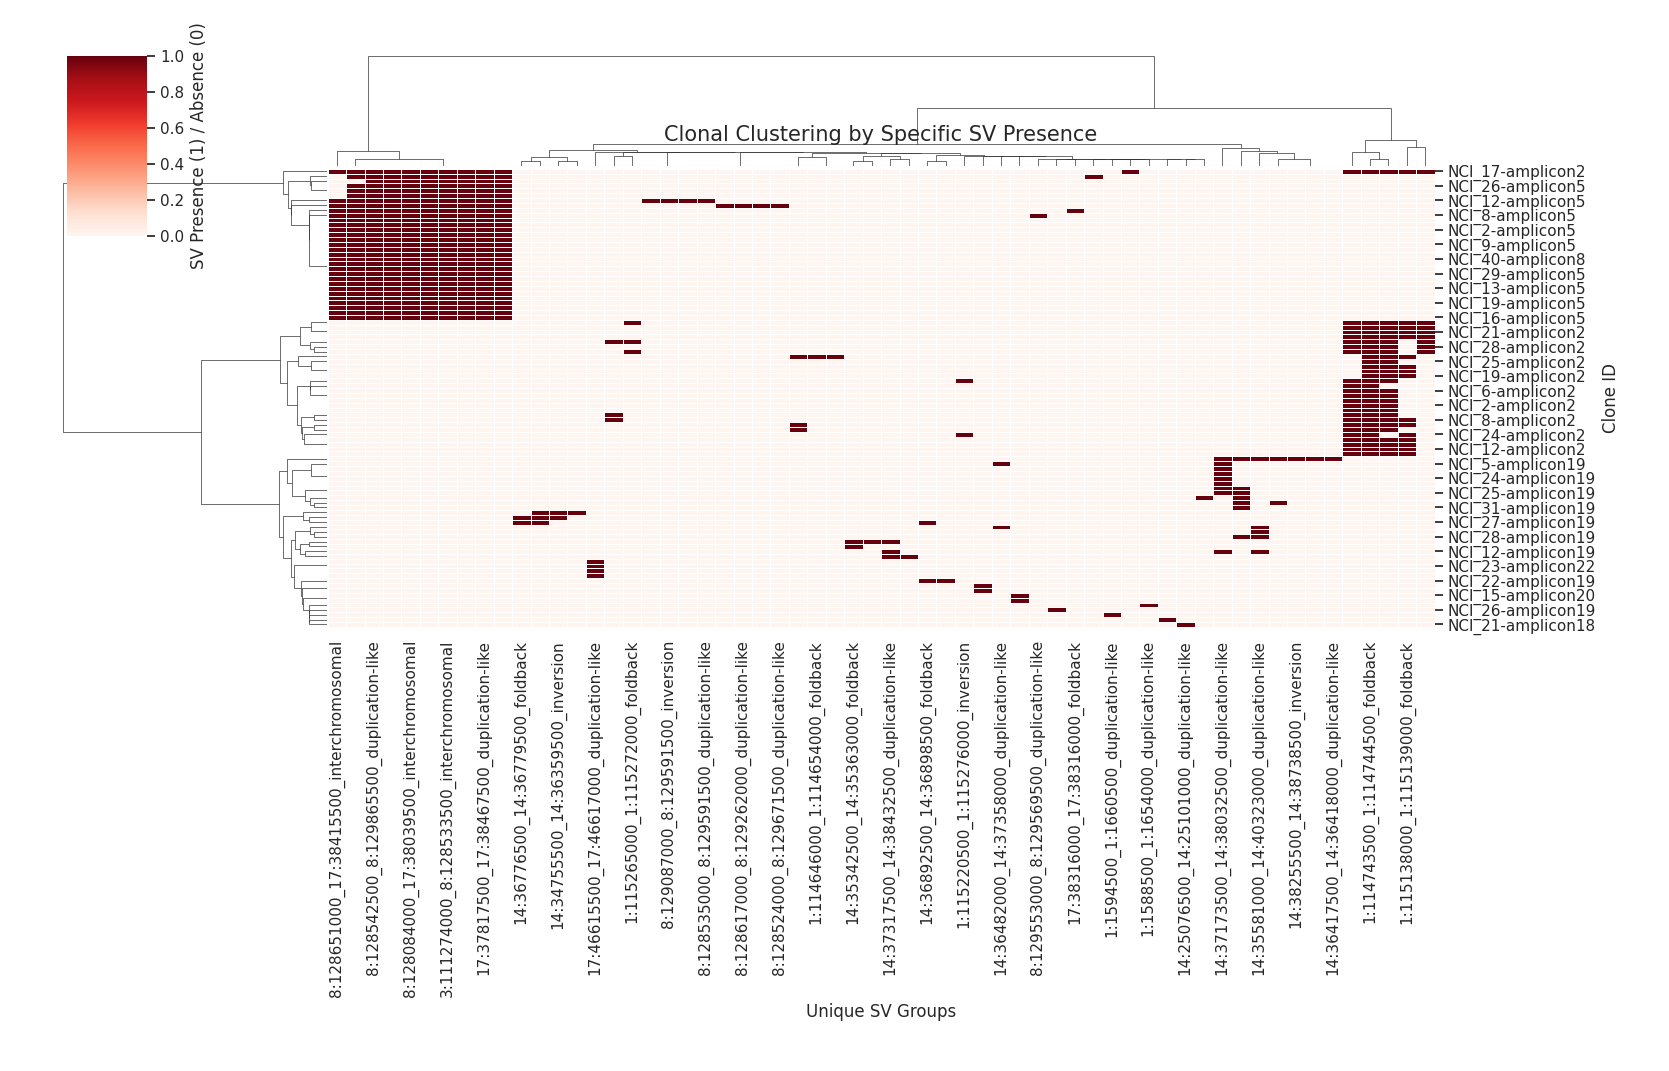

=== 클론별 할당된 SV 계통 클러스터 ===
           sample_amp Lineage_Cluster
0    NCI_17-amplicon2       Lineage_1
1    NCI_31-amplicon5       Lineage_1
2    NCI_28-amplicon5       Lineage_1
3    NCI_26-amplicon5       Lineage_1
4    NCI_21-amplicon5       Lineage_1
..                ...             ...
89   NCI_19-amplicon1       Lineage_4
90  NCI_26-amplicon19       Lineage_4
91   NCI_23-amplicon1       Lineage_4
92  NCI_20-amplicon19       Lineage_4
93  NCI_21-amplicon18       Lineage_4

[94 rows x 2 columns]


In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# 1. SV Presence/Absence 이진(Binary) 매트릭스 생성
# 행(Row): 클론 (sample_amp)
# 열(Column): 고유한 SV 그룹 (SV_Group)
sv_matrix = pd.crosstab(df['sample_amp'], df['SV_Group'])

# 개수(Count)가 아닌 존재 여부(1/0)로 변환
sv_matrix = (sv_matrix > 0).astype(int)

# 2. 계층적 군집화 및 히트맵(Clustermap) 시각화
# 이진 데이터(0, 1) 군집화에 적합한 설정 사용 (euclidean/ward 또는 jaccard/average)
g = sns.clustermap(sv_matrix, 
                   metric='euclidean', 
                   method='ward', 
                   cmap='Reds', # 1(있음)은 빨간색, 0(없음)은 흰색
                   figsize=(16, 10),
                   linewidths=0.5,
                   cbar_kws={'label': 'SV Presence (1) / Absence (0)'})

# 히트맵 제목 및 축 라벨 조정
g.ax_heatmap.set_title("Clonal Clustering by Specific SV Presence", pad=20, size=15)
g.ax_heatmap.set_xlabel("Unique SV Groups")
g.ax_heatmap.set_ylabel("Clone ID")
plt.show()

# 3. 덴드로그램(트리)을 잘라서 실제 클러스터 라벨(Sub-lineage) 부여하기
# 트리의 큰 가지(Branch)를 기준으로 그룹을 3~4개로 분할합니다. (t값 조절 가능)
num_clusters = 4
cluster_labels = fcluster(g.dendrogram_row.linkage, t=num_clusters, criterion='maxclust')

# 결과를 데이터프레임으로 정리하여 확인
cluster_df = pd.DataFrame({
    'sample_amp': sv_matrix.index[g.dendrogram_row.reordered_ind], # 히트맵 순서대로 정렬
    'Lineage_Cluster': [f"Lineage_{i}" for i in cluster_labels[g.dendrogram_row.reordered_ind]]
})

print("=== 클론별 할당된 SV 계통 클러스터 ===")
print(cluster_df)

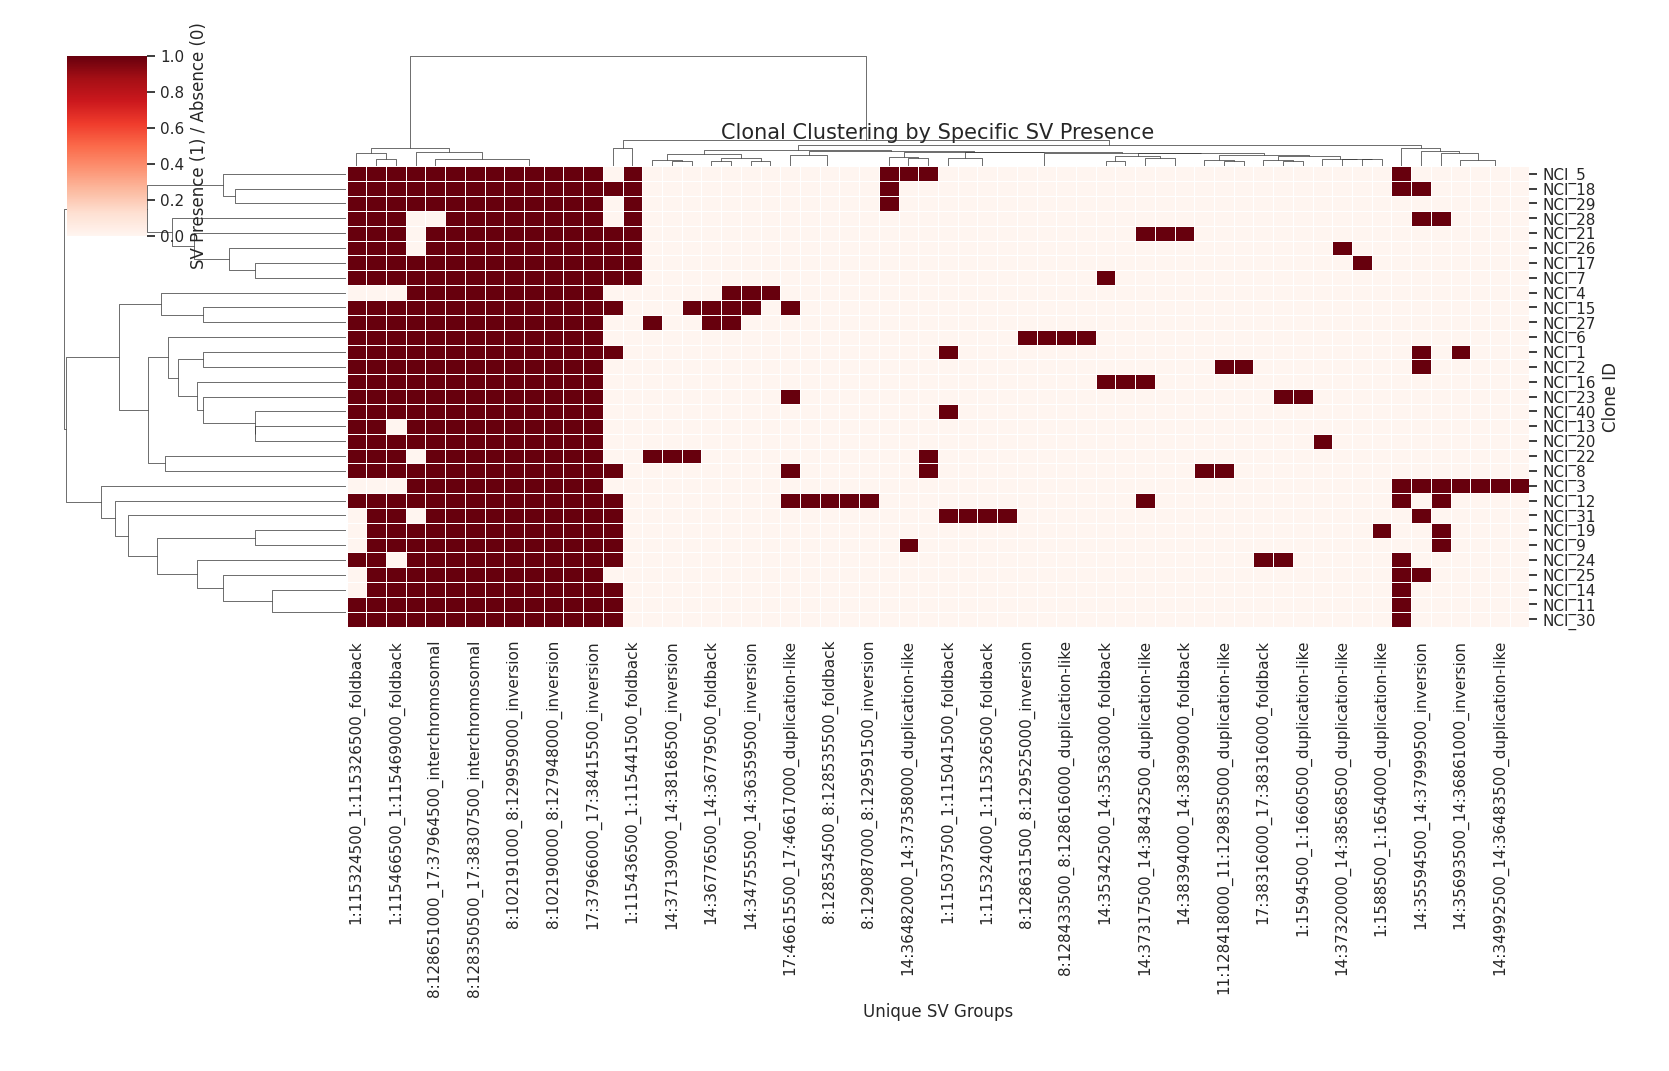

=== 클론별 할당된 SV 계통 클러스터 ===
   sample_amp Lineage_Cluster
0       NCI_5       Lineage_1
1      NCI_18       Lineage_1
2      NCI_29       Lineage_1
3      NCI_28       Lineage_1
4      NCI_21       Lineage_1
5      NCI_26       Lineage_1
6      NCI_17       Lineage_1
7       NCI_7       Lineage_1
8       NCI_4       Lineage_2
9      NCI_15       Lineage_2
10     NCI_27       Lineage_2
11      NCI_6       Lineage_2
12      NCI_1       Lineage_2
13      NCI_2       Lineage_2
14     NCI_16       Lineage_2
15     NCI_23       Lineage_2
16     NCI_40       Lineage_2
17     NCI_13       Lineage_2
18     NCI_20       Lineage_2
19     NCI_22       Lineage_2
20      NCI_8       Lineage_2
21      NCI_3       Lineage_4
22     NCI_12       Lineage_3
23     NCI_31       Lineage_3
24     NCI_19       Lineage_3
25      NCI_9       Lineage_3
26     NCI_24       Lineage_3
27     NCI_25       Lineage_3
28     NCI_14       Lineage_3
29     NCI_11       Lineage_3
30     NCI_30       Lineage_3


In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# 1. SV Presence/Absence 이진(Binary) 매트릭스 생성
# 행(Row): 클론 (sample_amp)
# 열(Column): 고유한 SV 그룹 (SV_Group)
sv_matrix = pd.crosstab(df['sample_id'], df['SV_Group'])

# 개수(Count)가 아닌 존재 여부(1/0)로 변환
sv_matrix = (sv_matrix > 0).astype(int)

# 2. 계층적 군집화 및 히트맵(Clustermap) 시각화
# 이진 데이터(0, 1) 군집화에 적합한 설정 사용 (euclidean/ward 또는 jaccard/average)
g = sns.clustermap(sv_matrix, 
                   metric='euclidean', 
                   method='ward', 
                   cmap='Reds', # 1(있음)은 빨간색, 0(없음)은 흰색
                   figsize=(16, 10),
                   linewidths=0.5,
                   cbar_kws={'label': 'SV Presence (1) / Absence (0)'})

# 히트맵 제목 및 축 라벨 조정
g.ax_heatmap.set_title("Clonal Clustering by Specific SV Presence", pad=20, size=15)
g.ax_heatmap.set_xlabel("Unique SV Groups")
g.ax_heatmap.set_ylabel("Clone ID")
plt.show()

# 3. 덴드로그램(트리)을 잘라서 실제 클러스터 라벨(Sub-lineage) 부여하기
# 트리의 큰 가지(Branch)를 기준으로 그룹을 3~4개로 분할합니다. (t값 조절 가능)
num_clusters = 4
cluster_labels = fcluster(g.dendrogram_row.linkage, t=num_clusters, criterion='maxclust')

# 결과를 데이터프레임으로 정리하여 확인
cluster_df = pd.DataFrame({
    'sample_amp': sv_matrix.index[g.dendrogram_row.reordered_ind], # 히트맵 순서대로 정렬
    'Lineage_Cluster': [f"Lineage_{i}" for i in cluster_labels[g.dendrogram_row.reordered_ind]]
})

print("=== 클론별 할당된 SV 계통 클러스터 ===")
print(cluster_df)

## structural retention analysis

1) interval 
2) Junction
3) structure transform

Observation: Parental ecDNA는 많은데 clone에서 ecDNA call이 감소
QC/Validation: 기술적 bias 여부 점검
Structural retention: interval/junction 기반으로 “진짜 소실 vs 형태전환” 판정
Architecture-aware clustering: oncogene CN + amplicon type 기반 clone grouping(heatmap)
Experiment plan: cluster별 대표 clone 선택 → therapy 투여 → resistance trajectory 비교
Next features: segment CN/complexity/SV(ERBB2 locus)/driver mutation 추가로 “mechanism-oriented stratification” 확장 제안

In [100]:
aa_cycles=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv')
# (3626, 11)

aa_cycles=pd.merge(aa_cycles, aaSuite_gemline_ms[['aa_barcode','amplicon_index','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_index'])
print(aa_cycles.shape) #(3626, 14)


# aa_cycles_ECGI = aa_cycles[(aa_cycles['source_barcode']=='ECGI1')&(aa_cycles['sample_id']!='EG_21')]

# print(aa_cycles_ECGI.shape) #(2901, 14)

# aa_cycles_ECGI.head(2)


aa_cycles.head(2)

(5303, 14)


,file_name,aa_barcode,amplicon_index,cycle_index,cycle_barcode,Copy_count,Length,IsCyclicPath,CycleClass,Segments,Intervals,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,cycle1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,2.750858,154981,False,Invalid,"0+,1-,0+\n",15:20824661-20979641,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,cycle1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,2.774022,265006,False,Linear,"0+,1-,0+\n",16:33268118-33533123,EFM19,EFM_5,Linear


In [101]:

def process_aa_cycles_to_cnv(df):
    """
    합쳐진 AA cycle 데이터를 정제하여 
    구간별 최종 Copy Number(CN)를 계산합니다.
    """
    # 1. Intervals 컬럼 분리 (예: "17:12624000-13920299")
    # 정규표현식을 사용해 chr, start, end를 추출합니다.
    coords = df['Intervals'].str.extract(r'(\d+):(\d+)-(\d+)')
    df['seqnames'] = 'chr' + coords[0]
    df['start'] = coords[1].astype(float)
    df['end'] = coords[2].astype(float)
    
    # 2. Copy_count를 수치형으로 변환
    df['copyNumber'] = pd.to_numeric(df['Copy_count'], errors='coerce')
    
    # 3. 중복 구간 통합 (가장 중요한 단계)
    # 동일한 앰플리콘 내에서 같은 좌표를 가진 조각들의 CN을 합산합니다.
    # AA 구조상 여러 Cycle이 같은 구간을 공유하면 실제 CN은 그 합입니다.
    final_cnv = df.groupby(
        ['aa_barcode', 'amplicon_index', 'seqnames', 'start', 'end']
    )['copyNumber'].sum().reset_index()
    
    # 컬럼명 정리 (김상현 선생님 코드 호환용)
    final_cnv = final_cnv.rename(columns={'amplicon_index': 'v'})
    
    return final_cnv

# --- 실행 예시 ---
# 박사님이 복사해주신 데이터를 df로 불러왔다고 가정할 때:
cnv_df = process_aa_cycles_to_cnv(aa_cycles)

# 확인용 출력
cnv_df.head()

,aa_barcode,v,seqnames,start,end,copyNumber
0,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,1318199.0,2.756051
1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,2224739.0,4.277366
2,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1004112.0,1004213.0,1.273404
3,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1199945.0,2120873.0,2.177285
4,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1912846.0,1913665.0,4.485499


In [102]:
aa_cycles=pd.merge(cnv_df, aaSuite_gemline_ms[['aa_barcode','amplicon_index','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_index'])


KeyError: 'amplicon_index'

In [103]:
aa_cycles.head(2)

aa_cycles['amplicon_type'].value_counts()

amplicon_type
Linear    2069
none      1620
ecDNA      868
BFB        391
CNC        355
Name: count, dtype: int64

In [104]:
# aa_cycles.to_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260320_processed_cycles_files.csv')
aa_cycles=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260320_processed_cycles_files.csv')

<Figure size 1400x1000 with 0 Axes>

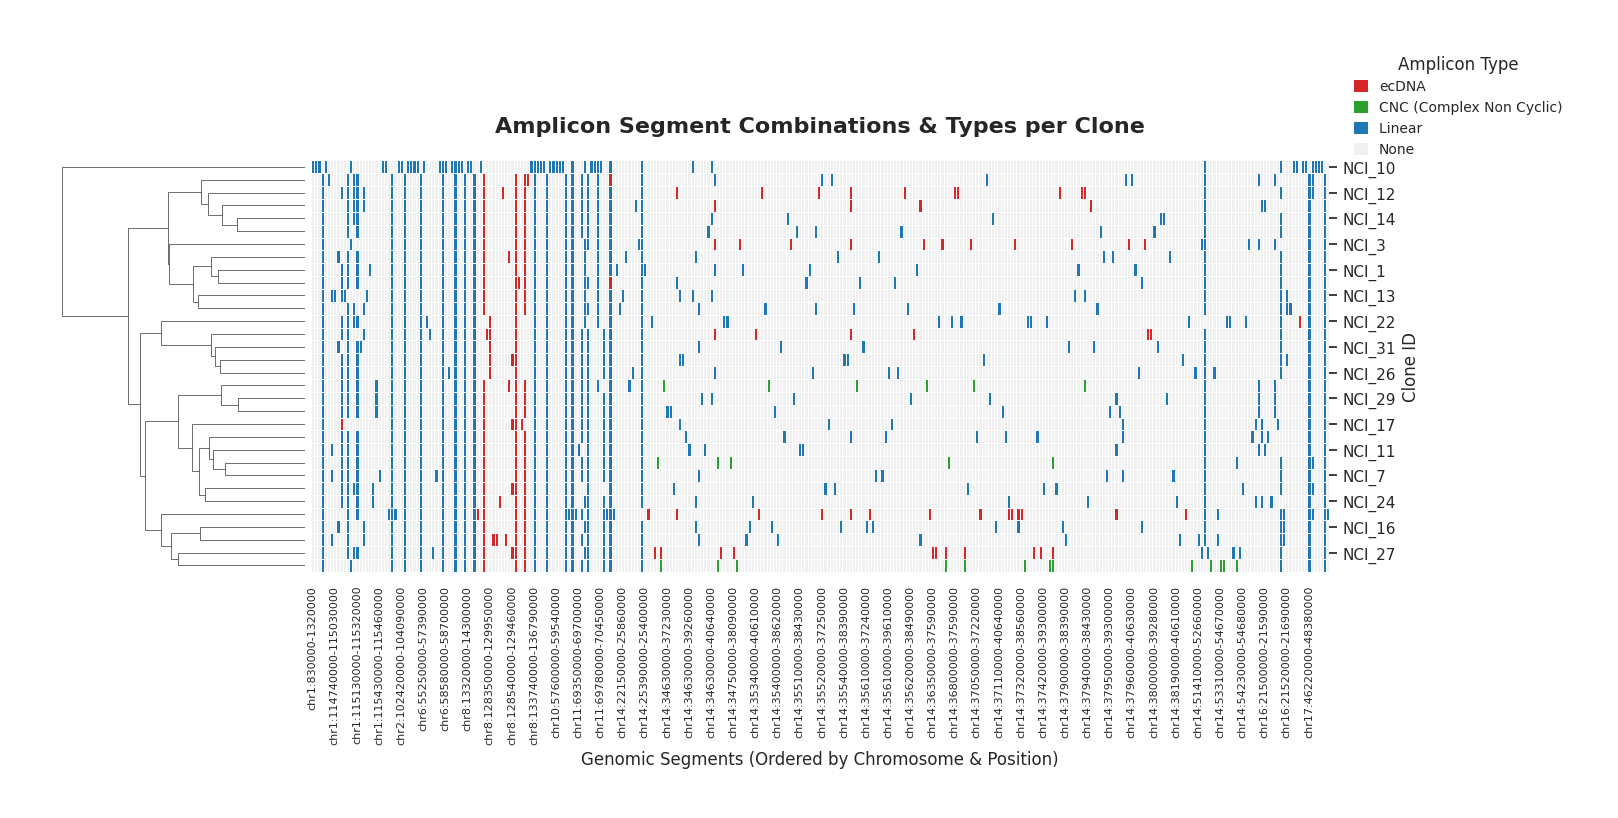

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# aa_cycles 데이터프레임이 'df_cycles'라는 이름으로 로드되어 있다고 가정합니다.
df_cycles = aa_cycles.copy()
df_cycles=df_cycles[df_cycles['source_barcode']==source]



# 1. Segment 위치 표준화 (10kb Binning)
# 미세하게 다른 좌표들을 같은 '블록'으로 인식하게 묶어줍니다.
bin_size = 10000
df_cycles['start_bin'] = (df_cycles['start'] // bin_size) * bin_size
df_cycles['end_bin'] = (df_cycles['end'] // bin_size) * bin_size

# 고유한 Segment ID 생성 (예: chr1:840000-1310000)
df_cycles['Segment_ID'] = df_cycles['seqnames'].astype(str) + ":" + \
                          df_cycles['start_bin'].astype(int).astype(str) + "-" + \
                          df_cycles['end_bin'].astype(int).astype(str)

# 2. Amplicon Type에 따른 우선순위 및 색상 매핑 값 부여
# 한 구역에 여러 타입이 겹칠 경우 ecDNA를 최우선으로 표시합니다.
type_mapping = {'ecDNA': 3, 'CNC': 2, 'Linear': 1, 'None': 0} # 0은 없음
df_cycles['type_score'] = df_cycles['amplicon_type'].map(type_mapping).fillna(1)

# 3. 클론(Row) x Segment(Column) 매트릭스 생성
# 값이 비어있는 곳은 0(없음)으로 채웁니다.
seg_matrix = df_cycles.pivot_table(index='sample_id', 
                                   columns='Segment_ID', 
                                   values='type_score', 
                                   aggfunc='max').fillna(0)

# 4. Segment(열)들을 염색체 순서 및 물리적 좌표 순서로 정렬!
def sort_segments(col_name):
    chrom, pos = col_name.split(':')
    start_pos = int(pos.split('-')[0])
    # chr 번호 추출 (X, Y 예외 처리)
    chrom_num = chrom.replace('chr', '')
    if chrom_num.isdigit(): chrom_num = int(chrom_num)
    elif chrom_num == 'X': chrom_num = 23
    elif chrom_num == 'Y': chrom_num = 24
    else: chrom_num = 99
    return (chrom_num, start_pos)

sorted_columns = sorted(seg_matrix.columns, key=sort_segments)
seg_matrix = seg_matrix[sorted_columns] # 정렬된 순서대로 컬럼 재배치

# 5. 시각화 (Clustermap을 이용한 OncoPrint 스타일)
# 색상 팔레트 정의 (0: 회색, 1: 파랑(Linear), 2: 초록(CNC), 3: 빨강(ecDNA))
cmap = mcolors.ListedColormap(['#f0f0f0', '#1f77b4', '#2ca02c', '#d62728'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(14, 10))

# col_cluster=False로 설정하여 X축(게놈 좌표 순서)이 섞이지 않게 고정합니다!
# row_cluster=True로 설정하여 "비슷한 조각을 가진 클론"끼리 자동으로 묶어줍니다.
g = sns.clustermap(seg_matrix, 
                   cmap=cmap, norm=norm,
                   col_cluster=False, 
                   row_cluster=True,
                   metric='jaccard', # 존재 여부 이진 데이터에 적합한 거리 계산
                   method='ward',
                   linewidths=0.5, linecolor='white',
                   figsize=(14, 8),
                   cbar_pos=None) # 기본 컬러바 숨김 (커스텀 범례 추가)

# 타이틀 및 라벨 조정
g.ax_heatmap.set_title("Amplicon Segment Combinations & Types per Clone", pad=20, size=16, fontweight='bold')
g.ax_heatmap.set_xlabel("Genomic Segments (Ordered by Chromosome & Position)", size=12)
g.ax_heatmap.set_ylabel("Clone ID", size=12)

# X축 라벨이 너무 많으면 지저분하므로 숨기거나 각도 조절
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, size=8)

# 6. 커스텀 범례(Legend) 추가
legend_patches = [
    mpatches.Patch(color='#d62728', label='ecDNA'),
    mpatches.Patch(color='#2ca02c', label='CNC (Complex Non Cyclic)'),
    mpatches.Patch(color='#1f77b4', label='Linear '),
    mpatches.Patch(color='#f0f0f0', label='None')
]
g.fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.1, 1.0), title="Amplicon Type", fontsize=10)

plt.show()

In [130]:
df[(df['sample_id']=='parental')&(df['amplicon_type']=='ecDNA')]['Intervals']

2395    8:43225919-43227230,14:32583156-32584467,14:34...
2411    3:111173429-111384740,8:102090543-102301854,8:...
Name: Intervals, dtype: object